In [1]:
!pip install tqdm

Looking in indexes: https://repomaster.deniz.denizbank.com/repository/intertech-pypi-group/simple


In [31]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

train_df = pd.read_csv("preprocessed_train_final.csv")
test_df  = pd.read_csv("preprocessed_test_final.csv")


/tmp/ipykernel_143675/622950258.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df  = pd.read_csv("preprocessed_test_final.csv")


In [ ]:
train_df.head(5)


In [4]:
train_df.columns

Index(['product_id', 'product_text', 'category', 'product_text_clean',
       'dominant_category', 'purity', 'total_cnt', 'canon_text',
       'text_for_model', 'char_len', 'tok_cnt', 'is_junk', 'cluster_id',
       'sample_weight', 'main_category', 'hash_text', 'fold2', 'mismatch_oof',
       'pred_category_oof', 'gap_oof', 'margin_oof', 'flag_suspect',
       'category_fixed', 'main_category_old', 'template_key', 'cnt',
       'is_coarse', 'desc_token', 'template_key_ref', 'grank', 'cat_cnt',
       'cap_cat', 'rank_cat', 'gsize', 'cap_key', 'rank_key'],
      dtype='object')

In [5]:
# Choose text column
TEXT_COL = "text_for_model"

LABEL_TRAIN = "category_fixed"

train_df[TEXT_COL] = train_df[TEXT_COL].fillna("").astype(str)
test_df[TEXT_COL]  = test_df[TEXT_COL].fillna("").astype(str)

print("Train:", train_df.shape, "| Test:", test_df.shape)
print("Train label col:", LABEL_TRAIN, "| Text col:", TEXT_COL)

Train: (2872653, 36) | Test: (1082903, 12)
Train label col: category_fixed | Text col: text_for_model


In [6]:
test_df = test_df.dropna(subset="category").reset_index(drop=True)


In [7]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

# Light clean (punct->space) for hashing model
def to_hash_text(s: pd.Series) -> pd.Series:
    return (s.str.lower()
              .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

train_df["hash_text"] = to_hash_text(train_df[TEXT_COL])
test_df["hash_text"]    = to_hash_text(test_df[TEXT_COL])

word_vec = HashingVectorizer(
    n_features=2**19, alternate_sign=False, norm="l2",
    analyzer="word", ngram_range=(1,2), lowercase=False
)
char_vec = HashingVectorizer(
    n_features=2**18, alternate_sign=False, norm="l2",
    analyzer="char_wb", ngram_range=(3,5), lowercase=False
)

def X_transform(text_series):
    return hstack([word_vec.transform(text_series), char_vec.transform(text_series)], format="csr")

# Label encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df[LABEL_TRAIN].astype(str).values)
y_test  = le.transform(test_df["category"].astype(str).values)  # assumes no new categories

n_classes = len(le.classes_)
print("Classes:", n_classes)

Classes: 1140


In [8]:
from sklearn.linear_model import SGDClassifier
from scipy.special import logsumexp
import numpy as np
from tqdm.auto import tqdm

def batch_logloss_from_scores(S, y, sample_weight=None):
    """
    Multi-class log-loss computed from raw scores S (decision_function output).
    loss_i = - (s_true - logsumexp(scores))
    """
    if S.ndim == 1:  # binary guard
        S = np.vstack([-S, S]).T

    lse = logsumexp(S, axis=1)
    s_true = S[np.arange(len(y)), y]
    loss = -(s_true - lse)

    if sample_weight is None:
        return float(loss.mean())
    sw = sample_weight.astype(np.float64)
    return float(np.sum(sw * loss) / np.sum(sw))

clf = SGDClassifier(
    loss="log_loss",
    alpha=5e-6,
    penalty="l2",
    max_iter=1,
    tol=None,
    n_jobs=-1,
    random_state=42,
    average=True
)

BATCH = 1_000_000
EPOCHS = 2

PRINT_EVERY = 20   # print every N batches (e.g., 10, 20, 50)
rng = np.random.RandomState(42)

idx = np.arange(len(train_df))
classes_int = np.arange(n_classes, dtype=np.int32)

global_step = 0
running_loss = 0.0
running_w = 0.0

for ep in range(EPOCHS):
    rng.shuffle(idx)
    for start in tqdm(range(0, len(idx), BATCH), desc=f"Train epoch {ep+1}/{EPOCHS}"):
        b = idx[start:start+BATCH]

        Xb = X_transform(train_df["hash_text"].iloc[b])
        yb = y_train[b]
        wb = train_df["sample_weight"].iloc[b].values.astype(np.float32)

        # update
        if ep == 0 and start == 0:
            clf.partial_fit(Xb, yb, classes=classes_int, sample_weight=wb)
        else:
            clf.partial_fit(Xb, yb, sample_weight=wb)

        global_step += 1

        # print loss sometimes (on current batch, after update)
        if global_step % PRINT_EVERY == 0:
            S = clf.decision_function(Xb)
            loss_val = batch_logloss_from_scores(S, yb, wb)

            # optional: batch accuracy for sanity
            if np.ndim(S) == 1:
                S = np.vstack([-S, S]).T
            pred_b = S.argmax(axis=1)
            acc_b = float((pred_b == yb).mean())

            # running weighted loss (rough)
            running_loss = 0.9 * running_loss + 0.1 * loss_val
            print(f"[ep {ep+1}] step {global_step:>6} | batch_logloss={loss_val:.4f} | batch_acc={acc_b:.4f} | smooth_loss={running_loss:.4f}")

print("Training done.")

Train epoch 1/2:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch 2/2:   0%|          | 0/3 [00:00<?, ?it/s]

Training done.


In [9]:
from sklearn.metrics import accuracy_score, f1_score

N = len(test_df)
pred_int = np.empty(N, dtype=np.int32)
top5_ok  = np.zeros(N, dtype=bool)
gap      = np.zeros(N, dtype=np.float32)     # top1_score - true_score
margin   = np.zeros(N, dtype=np.float32)     # top1_score - second_score

SCORE_BATCH = 1_000_000

for start in tqdm(range(0, N, SCORE_BATCH), desc="Scoring test"):
    end = min(start + SCORE_BATCH, N)
    Xb = X_transform(test_df["hash_text"].iloc[start:end])

    S = clf.decision_function(Xb)
    if S.ndim == 1:  # binary guard
        S = np.vstack([-S, S]).T
    S = S.astype(np.float32)

    pred = S.argmax(axis=1)
    pred_int[start:end] = pred

    # top5
    k = 5
    topk = np.argpartition(-S, kth=min(k, S.shape[1]-1), axis=1)[:, :k]
    yt = y_test[start:end]
    top5_ok[start:end] = np.any(topk == yt[:, None], axis=1)

    # scores for gap/margin
    top1 = S[np.arange(end-start), pred]
    second = np.partition(S, -2, axis=1)[:, -2]
    margin[start:end] = (top1 - second)

    true_s = S[np.arange(end-start), yt]
    gap[start:end] = (top1 - true_s)

y_pred = le.inverse_transform(pred_int)

acc1 = accuracy_score(test_df["category"].astype(str).values, y_pred)
top5 = float(top5_ok.mean())
macf = f1_score(test_df["category"].astype(str).values, y_pred, average="macro")

print("Test Top-1 Acc :", acc1)
print("Test Top-5 Acc :", top5)
print("Test Macro-F1  :", macf)

test_df["pred_category_baseline"] = y_pred
test_df["gap_baseline"] = gap
test_df["margin_baseline"] = margin
test_df["mismatch_baseline"] = (test_df["pred_category_baseline"].astype(str) != test_df["category"].astype(str))

Scoring test:   0%|          | 0/2 [00:00<?, ?it/s]

Test Top-1 Acc : 0.8347928388652333
Test Top-5 Acc : 0.9455287233089636
Test Macro-F1  : 0.6749297529176846


In [3]:
import json
category_mapping = json.load(open('category_map.json', 'r', encoding='utf-8'))


In [11]:
# same rule you used: map -> fillna('Diğer')
test_df["main_category"] = test_df["pred_category_baseline"].map(category_mapping).fillna("Diğer")
display(test_df["main_category"].value_counts().head(20))


main_category
Ev & Yaşam      348336
Giyim           166795
Aksesuar        154305
Otomotiv        133118
Elektronik      116848
Kozmetik         49737
Ayakkabı         48551
Oyuncak          35390
Anne & Bebek     18199
Spor             11622
Name: count, dtype: int64

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# --- edit if needed ---
PRED_COL = "pred_category_baseline"
TRUE_COL = "category"

# optional: evaluate against fixed labels (NOT official)
TRUE_FIXED_COL = "category_fixed" if "category_fixed" in test_df.columns else None

TEXT_COL = "canon_text" if "canon_text" in test_df.columns else "product_text"
LABEL_TRAIN = "category_fixed" if "category_fixed" in train_df.columns else "category"


test_df = test_df.copy()

test_df[TRUE_COL] = test_df[TRUE_COL].astype(str)
test_df[PRED_COL] = test_df[PRED_COL].astype(str)

# mismatch if not present
if "mismatch_baseline" not in test_df.columns:
    test_df["mismatch_baseline"] = (test_df[PRED_COL] != test_df[TRUE_COL])

# main categories
test_df["main_true"] = test_df[TRUE_COL].map(category_mapping).fillna("Diğer")
test_df["main_pred"] = test_df[PRED_COL].map(category_mapping).fillna("Diğer")

print("Rows:", len(test_df))
print("Unique true leaf:", test_df[TRUE_COL].nunique(), "| unique pred leaf:", test_df[PRED_COL].nunique())
print("Unique main_true:", test_df["main_true"].nunique(), "| unique main_pred:", test_df["main_pred"].nunique())

Rows: 1082901
Unique true leaf: 1140 | unique pred leaf: 1067
Unique main_true: 10 | unique main_pred: 10


In [13]:
y_true = test_df[TRUE_COL].values
y_pred = test_df[PRED_COL].values

acc = accuracy_score(y_true, y_pred)
mac = f1_score(y_true, y_pred, average="macro")
mic = f1_score(y_true, y_pred, average="micro")
w_f = f1_score(y_true, y_pred, average="weighted")

print(f"ALL TEST | Top-1 Acc={acc:.4f} | Macro-F1={mac:.4f} | Micro-F1={mic:.4f} | Weighted-F1={w_f:.4f}")

# optional: also show against "category_fixed" if present (not official)
if TRUE_FIXED_COL:
    y_true2 = test_df[TRUE_FIXED_COL].astype(str).values
    acc2 = accuracy_score(y_true2, y_pred)
    mac2 = f1_score(y_true2, y_pred, average="macro")
    print(f"(Noise-analysis) vs category_fixed | Acc={acc2:.4f} | Macro-F1={mac2:.4f}")

ALL TEST | Top-1 Acc=0.8348 | Macro-F1=0.6749 | Micro-F1=0.8348 | Weighted-F1=0.8242


In [14]:
# train counts based on TRAIN label column
train_counts = train_df[LABEL_TRAIN].astype(str).value_counts()
test_df["train_freq"] = test_df[TRUE_COL].map(train_counts).fillna(0).astype(int)

bins = [-1, 200, 500, 2000, 10000, 10**18]
names = ["<=200", "201-500", "501-2k", "2k-10k", ">10k"]
test_df["freq_bin"] = pd.cut(test_df["train_freq"], bins=bins, labels=names)

rows = []
for b in names:
    m = (test_df["freq_bin"] == b).values
    yt = test_df.loc[m, TRUE_COL].values
    yp = test_df.loc[m, PRED_COL].values
    if len(yt) == 0:
        continue
    rows.append({
        "freq_bin": b,
        "n_test": len(yt),
        "avg_train_freq": float(test_df.loc[m, "train_freq"].mean()),
        "acc": accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro"),
        "micro_f1": f1_score(yt, yp, average="micro"),
    })

tail_df = pd.DataFrame(rows)
display(tail_df)

,freq_bin,n_test,avg_train_freq,acc,macro_f1,micro_f1
0,<=200,7237,105.399060,0.013127,0.004698,0.013127
1,201-500,21069,383.253500,0.401253,0.101225,0.401253
2,501-2k,167329,1166.059882,0.694500,0.362660,0.694500
3,2k-10k,685565,5937.118491,0.863532,0.316053,0.863532
4,>10k,201701,11892.303127,0.928265,0.078013,0.928265


In [15]:
# main-level metrics
acc_main = accuracy_score(test_df["main_true"], test_df["main_pred"])
mac_main = f1_score(test_df["main_true"], test_df["main_pred"], average="macro")
print(f"MAIN-CAT | Acc={acc_main:.4f} | Macro-F1={mac_main:.4f}")

# conditional leaf accuracy given main correct
main_ok = (test_df["main_true"] == test_df["main_pred"]).values
acc_leaf_cond = accuracy_score(test_df.loc[main_ok, TRUE_COL], test_df.loc[main_ok, PRED_COL]) if main_ok.sum() else np.nan
mac_leaf_cond = f1_score(test_df.loc[main_ok, TRUE_COL], test_df.loc[main_ok, PRED_COL], average="macro") if main_ok.sum() else np.nan

print(f"LEAF | Given main correct: n={main_ok.sum()} | Acc={acc_leaf_cond:.4f} | Macro-F1={mac_leaf_cond:.4f}")

# per-main breakdown
per_main = (test_df.groupby("main_true")
            .apply(lambda g: pd.Series({
                "n": len(g),
                "leaf_acc": accuracy_score(g[TRUE_COL], g[PRED_COL]),
                "leaf_macroF1": f1_score(g[TRUE_COL], g[PRED_COL], average="macro"),
            }))
            .sort_values("n", ascending=False))
display(per_main)

MAIN-CAT | Acc=0.9603 | Macro-F1=0.9288
LEAF | Given main correct: n=1039918 | Acc=0.8693 | Macro-F1=0.7276


/tmp/ipykernel_1417536/1797292084.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,n,leaf_acc,leaf_macroF1
main_true,,,
Ev & Yaşam,348009.0,0.817163,0.388034
Giyim,164061.0,0.801470,0.180332
Aksesuar,155289.0,0.850453,0.124090
Otomotiv,131609.0,0.928303,0.117996
Elektronik,115721.0,0.920585,0.174872
Kozmetik,50078.0,0.810815,0.164533
Ayakkabı,48972.0,0.777669,0.094266
Oyuncak,34414.0,0.714767,0.056304
Anne & Bebek,22529.0,0.657375,0.090351


In [16]:
pairs = (test_df.groupby([TRUE_COL, PRED_COL])
         .size()
         .reset_index(name="cnt")
         .sort_values("cnt", ascending=False))

true_cnt = test_df[TRUE_COL].value_counts().rename("true_cnt").reset_index().rename(columns={"index": TRUE_COL})
pairs = pairs.merge(true_cnt, on=TRUE_COL, how="left")
pairs["rate_of_true"] = pairs["cnt"] / pairs["true_cnt"]

print("Top confusion pairs by COUNT:")
display(pairs.head(30))

# show high-rate confusions but avoid tiny denominators (e.g. true_cnt >= 50)
min_true = 50
pairs2 = pairs[pairs["true_cnt"] >= min_true].sort_values("rate_of_true", ascending=False)

print(f"Top confusion pairs by RATE (true_cnt>={min_true}):")
display(pairs2.head(30))

Top confusion pairs by COUNT:


,category,pred_category_baseline,cnt,true_cnt,rate_of_true
0,Oto Boya,Oto Boya,9753,9839,0.991259
1,Oto Branda,Oto Branda,9645,9667,0.997724
2,Oto Paspasları,Oto Paspasları,9449,9778,0.966353
3,Rozet,Rozet,8770,8791,0.997611
4,Bardak Altlığı,Bardak Altlığı,8631,8706,0.991385
5,Yazıcı Sarf Malzemeleri,Yazıcı Sarf Malzemeleri,8459,9456,0.894564
6,Kupalar,Kupalar,8386,8683,0.965795
7,Araç İçi Telefon Tutucu,Araç İçi Telefon Tutucu,7788,7974,0.976674
8,"Kartuş, Toner & Drum","Kartuş, Toner & Drum",7669,7956,0.963927
9,Saat,Saat,7522,7757,0.969705


Top confusion pairs by RATE (true_cnt>=50):


,category,pred_category_baseline,cnt,true_cnt,rate_of_true
1,Oto Branda,Oto Branda,9645,9667,0.997724
3,Rozet,Rozet,8770,8791,0.997611
96,TV Ekran Koruyucular,TV Ekran Koruyucular,2677,2686,0.996649
252,Dizüstü Bilgisayar,Dizüstü Bilgisayar,821,825,0.995152
191,Kravat,Kravat,1169,1175,0.994894
22,Bluetooth Araç Kiti,Bluetooth Araç Kiti,6141,6179,0.993850
84,Powerbank,Powerbank,3013,3033,0.993406
70,Lastik,Lastik,3660,3689,0.992139
345,Sanal Gerçeklik Gözlüğü,Sanal Gerçeklik Gözlüğü,579,584,0.991438
4,Bardak Altlığı,Bardak Altlığı,8631,8706,0.991385


,coverage,n_kept,acc_on_kept,margin_threshold
0,1.00,1082901,0.834793,0.000010
1,0.99,1072071,0.840277,0.085185
2,0.98,1061242,0.845577,0.174773
3,0.95,1028755,0.860593,0.469868
4,0.90,974610,0.881446,1.027816
5,0.80,866320,0.911022,2.191306
6,0.70,758030,0.930115,3.214495
7,0.50,541450,0.955218,4.921500


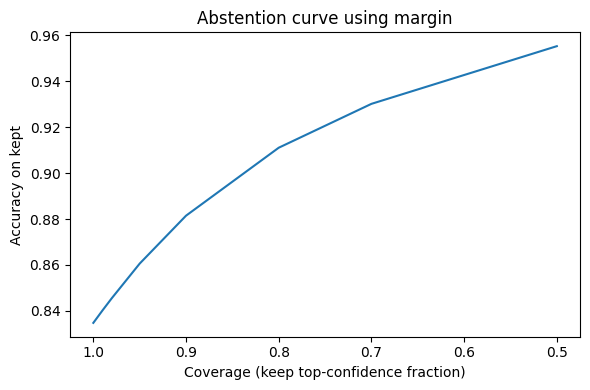

In [17]:
assert "margin_baseline" in test_df.columns, "Need margin_baseline to build abstention curve"

marg = test_df["margin_baseline"].values.astype(float)
ok = (test_df[PRED_COL].values == test_df[TRUE_COL].values)

# sort by confidence descending
order = np.argsort(-marg)
marg_s = marg[order]
ok_s = ok[order]

# evaluate at these coverages
coverages = [1.00, 0.99, 0.98, 0.95, 0.90, 0.80, 0.70, 0.50]
rows = []
N = len(test_df)

for c in coverages:
    k = int(N * c)
    k = max(1, k)
    acc_c = float(ok_s[:k].mean())
    thr = float(marg_s[k-1])
    rows.append({"coverage": c, "n_kept": k, "acc_on_kept": acc_c, "margin_threshold": thr})

abst_df = pd.DataFrame(rows)
display(abst_df)

# plot coverage vs accuracy
plt.figure(figsize=(6,4))
plt.plot(abst_df["coverage"], abst_df["acc_on_kept"])
plt.gca().invert_xaxis()
plt.xlabel("Coverage (keep top-confidence fraction)")
plt.ylabel("Accuracy on kept")
plt.title("Abstention curve using margin")
plt.tight_layout()
plt.show()

In [18]:
# Your suspect rule (as you defined)
def eval_slice(mask, name):
    yt = y_true[mask]
    yp = y_pred[mask]
    acc = accuracy_score(yt, yp)
    mac = f1_score(yt, yp, average="macro")
    print(f"{name}: n={mask.sum()} | acc={acc:.4f} | macroF1={mac: .4f}")
    
suspect = (test_df["mismatch_baseline"].values &
           (test_df["gap_baseline"].values > 0.5) &
           (test_df["margin_baseline"].values > 0.3))

test_df["flag_suspect"] = suspect
print("Suspect rate:", test_df["flag_suspect"].mean(), "| count:", int(test_df["flag_suspect"].sum()))

# metrics excluding suspect (still evaluated against original labels, just shows sensitivity)
eval_slice(~test_df["flag_suspect"].values, "NOT-SUSPECT")
eval_slice(test_df["flag_suspect"].values, "SUSPECT")

# per-main suspect rate
sus_by_main = (test_df.groupby("main_true")["flag_suspect"].mean().sort_values(ascending=False))
display(sus_by_main)

Suspect rate: 0.13716674008057986 | count: 148538
NOT-SUSPECT: n=934363 | acc=0.9675 | macroF1= 0.8528
SUSPECT: n=148538 | acc=0.0000 | macroF1= 0.0000


main_true
Anne & Bebek    0.280128
Oyuncak         0.221334
Ayakkabı        0.201115
Spor            0.194451
Giyim           0.175672
Ev & Yaşam      0.149916
Kozmetik        0.143177
Aksesuar        0.126319
Elektronik      0.062478
Otomotiv        0.056045
Name: flag_suspect, dtype: float64

In [19]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# --- sanity checks ---
for name in ["clf", "le", "X_transform"]:
    if name not in globals():
        raise ValueError(f"Missing {name} in memory. Train the baseline first (clf, le, X_transform).")

if "hash_text" not in test_df.columns:
    raise ValueError("test_df needs 'hash_text' (run your hashing text preprocessing first).")

N = len(test_df)
K = 5
BATCH = 20_000

top1 = np.empty(N, dtype=object)
top3 = np.empty(N, dtype=object)  # each entry will be a list of 3 labels
top5 = np.empty(N, dtype=object)  # each entry will be a list of 5 labels

top3_scores = np.empty(N, dtype=object)  # list of 3 scores
top5_scores = np.empty(N, dtype=object)  # list of 5 scores

classes = le.classes_  # numpy array of label strings

for start in tqdm(range(0, N, BATCH), desc="Top-k scoring"):
    end = min(start + BATCH, N)
    Xb = X_transform(test_df["hash_text"].iloc[start:end])

    S = clf.decision_function(Xb)
    if S.ndim == 1:  # binary guard
        S = np.vstack([-S, S]).T

    # get top-K indices (unsorted)
    idx_topk = np.argpartition(-S, kth=K-1, axis=1)[:, :K]
    scr_topk = S[np.arange(end-start)[:, None], idx_topk]

    # sort the top-K by score descending
    order = np.argsort(-scr_topk, axis=1)
    idx_sorted = idx_topk[np.arange(end-start)[:, None], order]
    scr_sorted = scr_topk[np.arange(end-start)[:, None], order]

    labels_sorted = classes[idx_sorted]  # shape (batch, K)

    # fill outputs
    top1[start:end] = labels_sorted[:, 0]

    for i in range(end-start):
        top3[start+i] = labels_sorted[i, :3].tolist()
        top5[start+i] = labels_sorted[i, :5].tolist()
        top3_scores[start+i] = scr_sorted[i, :3].tolist()
        top5_scores[start+i] = scr_sorted[i, :5].tolist()

test_df["pred_top1"] = top1
test_df["pred_top3"] = top3
test_df["pred_top5"] = top5
test_df["score_top3"] = top3_scores
test_df["score_top5"] = top5_scores

display(test_df[["pred_top1", "pred_top3", "pred_top5"]].head(10))

Top-k scoring:   0%|          | 0/55 [00:00<?, ?it/s]

,pred_top1,pred_top3,pred_top5
0,Terlik,"[Terlik, Casual Ayakkabı, Ev Terliği]","[Terlik, Casual Ayakkabı, Ev Terliği, Spor T-S..."
1,Çorap,"[Çorap, Bijuteri Bileklik, Gümüş Bileklik]","[Çorap, Bijuteri Bileklik, Gümüş Bileklik, Kül..."
2,Askı,"[Askı, Pantolon Askısı, Eşarp]","[Askı, Pantolon Askısı, Eşarp, Pantolon, Mobil..."
3,Eşofman Altı,"[Eşofman Altı, Eşofman Takımı, Büyük Beden Swe...","[Eşofman Altı, Eşofman Takımı, Büyük Beden Swe..."
4,Bijuteri Yüzük,"[Bijuteri Yüzük, Gümüş Yüzük, Bijuteri Takım]","[Bijuteri Yüzük, Gümüş Yüzük, Bijuteri Takım, ..."
5,Saat,"[Saat, Duvar Saati, Akıllı Saat]","[Saat, Duvar Saati, Akıllı Saat, Masa Saati, K..."
6,Runner&Amerikan Servisi,"[Runner&Amerikan Servisi, Yapay & Kuru Çiçek, ...","[Runner&Amerikan Servisi, Yapay & Kuru Çiçek, ..."
7,Bebek Şampuanı,"[Bebek Şampuanı, Şampuan, Model Bebek]","[Bebek Şampuanı, Şampuan, Model Bebek, Bebek K..."
8,Çocuk Halısı,"[Çocuk Halısı, Çocuk Odası Avize, Koleksiyon]","[Çocuk Halısı, Çocuk Odası Avize, Koleksiyon, ..."
9,Motosiklet Yedek Parçalar,"[Motosiklet Yedek Parçalar, Otomobil Yedek Par...","[Motosiklet Yedek Parçalar, Otomobil Yedek Par..."


In [20]:
if "category" in test_df.columns:
    y_true = test_df["category"].astype(str).values
    top3_ok = np.array([y_true[i] in test_df["pred_top3"].iloc[i] for i in range(len(test_df))])
    top5_ok = np.array([y_true[i] in test_df["pred_top5"].iloc[i] for i in range(len(test_df))])

    print("Top-3 accuracy:", top3_ok.mean())
    print("Top-5 accuracy:", top5_ok.mean())

Top-3 accuracy: 0.9277717907731178
Top-5 accuracy: 0.9455287233089636


In [21]:
import os, json, numpy as np, pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)
from sklearn.metrics import f1_score, accuracy_score

In [22]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ---- columns (edit if yours differ) ----
TEXT_COL = "text_for_model"          # or "text_for_model"
LABEL_COL = "category_fixed"     # your fixed train labels
WEIGHT_COL = "sample_weight"     # your downweight column

# flags (optional)
JUNK_COL = "is_junk"             # optional
LEAK_COL = "is_exact_leak"       # optional

# ---- model ----
MODEL_NAME = "Trendyol/tyroberta"  # strong for TR+EN mix
# MODEL_NAME = "dbmdz/bert-base-turkish-cased"  # also good

MAX_LEN = 64  # titles are short; 64 or 80 is usually enough
SEED = 42

In [23]:
train_df['product_id'] = train_df['product_id'].astype(str)
test_df['product_id'] = test_df['product_id'].astype(str)

train_ds = Dataset.from_pandas(train_df)
test_ds   = Dataset.from_pandas(test_df)

In [24]:
# sanity: required columns
for c in [TEXT_COL, LABEL_COL]:
    if c not in train_ds.column_names:
        raise ValueError(f"train missing required column: {c}")
for c in [TEXT_COL, "category"]:  # test has ground truth category in your case
    if c not in test_ds.column_names:
        raise ValueError(f"test missing required column: {c}")

# add weights if missing
if WEIGHT_COL not in train_ds.column_names:
    train_ds = train_ds.add_column(WEIGHT_COL, [1.0] * len(train_ds))
if WEIGHT_COL not in test_ds.column_names:
    test_ds = test_ds.add_column(WEIGHT_COL, [1.0] * len(test_ds))

# optional: filter train
if JUNK_COL in train_ds.column_names:
    train_ds = train_ds.filter(lambda x: not x[JUNK_COL])
if LEAK_COL in train_ds.column_names:
    train_ds = train_ds.filter(lambda x: not x[LEAK_COL])

print("Train after filtering:", len(train_ds))
print("Test size:", len(test_ds))

Filter:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Train after filtering: 2872653
Test size: 1082901


In [25]:
# Build label list from train (string labels)
labels = sorted(set(train_ds[LABEL_COL]))
label2id = {lab:i for i, lab in enumerate(labels)}
id2label = {i:lab for lab, i in label2id.items()}

num_labels = len(labels)
print("num_labels:", num_labels)

# Map to integer labels for train
def map_train_label(batch):
    return {"labels": [label2id[x] for x in batch[LABEL_COL]]}

train_ds = train_ds.map(map_train_label, batched=True, desc="Mapping train labels")

# Map test "category" into label ids (for evaluation). If some label not found -> set -1.
def map_test_label(batch):
    out = []
    for x in batch["category"]:
        out.append(label2id.get(x, -1))
    return {"labels": out}

test_ds = test_ds.map(map_test_label, batched=True, desc="Mapping test labels")

# (Optional) check unknown labels in test
unknown = sum([1 for x in test_ds["labels"] if x == -1])
print("Unknown test labels (not in train):", unknown)

num_labels: 1140


Mapping train labels:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Mapping test labels:   0%|          | 0/1082901 [00:00<?, ? examples/s]

Unknown test labels (not in train): 0


In [26]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LEN
    )

train_tok = train_ds.map(tokenize, batched=True, remove_columns=[], desc="Tokenizing train")
test_tok  = test_ds.map(tokenize, batched=True, remove_columns=[], desc="Tokenizing test")

# Keep only columns needed by Trainer + your weight
keep_cols = {"input_ids", "attention_mask", "labels", WEIGHT_COL}
if "token_type_ids" in train_tok.column_names:
    keep_cols.add("token_type_ids")

train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in keep_cols])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Tokenizing train:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/1082901 [00:00<?, ? examples/s]

In [27]:
import torch
import torch.nn.functional as F

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = inputs.pop(WEIGHT_COL, None)
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Ignore unknown test labels (-1) safely (mainly relevant during eval)
        if labels is not None and (labels.min() < 0):
            mask = labels >= 0
            logits = logits[mask]
            labels = labels[mask]
            if weights is not None:
                weights = weights[mask]

        loss_vec = F.cross_entropy(logits, labels, reduction="none")

        if weights is None:
            loss = loss_vec.mean()
        else:
            weights = weights.to(loss_vec.dtype)
            loss = (loss_vec * weights).sum() / (weights.sum() + 1e-12)

        return (loss, outputs) if return_outputs else loss

In [28]:
def topk_acc(logits, labels, k=5):
    # labels may contain -1 (unknown); ignore them
    labels = np.asarray(labels)
    mask = labels >= 0
    if mask.sum() == 0:
        return np.nan
    logits = logits[mask]
    labels = labels[mask]
    topk = np.argpartition(-logits, kth=min(k, logits.shape[1]-1), axis=1)[:, :k]
    return float(np.mean([labels[i] in topk[i] for i in range(len(labels))]))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    labels = np.asarray(labels)
    mask = labels >= 0
    logits = logits[mask]
    labels = labels[mask]
    preds = preds[mask]

    out = {}
    out["acc"] = accuracy_score(labels, preds)
    out["macro_f1"] = f1_score(labels, preds, average="macro")
    out["top3_acc"] = topk_acc(logits, labels, k=3)
    out["top5_acc"] = topk_acc(logits, labels, k=5)
    return out

In [29]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [40]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# A100: prefer bf16
args = TrainingArguments(
    output_dir="bert_taxonomy_out",
    seed=SEED,

    # train
    num_train_epochs=1,
    max_steps=10_000,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,

    per_device_train_batch_size=64,     # A100 20GB + MAX_LEN=64 usually OK
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,

    bf16=True,                          # A100 supports bf16 well
    fp16=False,

    eval_strategy="steps",
    eval_steps=5000,
    logging_steps=200,
    save_steps=5000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none",                   # change to "tensorboard" if you want
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Trendyol/tyroberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [41]:
train_result = trainer.train()
print(train_result)

eval_result = trainer.evaluate()
print(eval_result)

# Save label mapping (handy for later inference)
with open("bert_taxonomy_out/label2id.json", "w", encoding="utf-8") as f:
    json.dump(label2id, f, ensure_ascii=False, indent=2)

Step,Training Loss,Validation Loss,Acc,Macro F1,Top3 Acc,Top5 Acc
5000,1.133382,1.146834,0.792626,0.480513,0.896465,0.922642
10000,0.871149,0.950503,0.818564,0.560631,0.919052,0.939305


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=10000, training_loss=1.7596445877075195, metrics={'train_runtime': 1905.2846, 'train_samples_per_second': 335.908, 'train_steps_per_second': 5.249, 'total_flos': 9467842151586816.0, 'train_loss': 1.7596445877075195, 'epoch': 0.222786614980172})


{'eval_loss': 0.9505028128623962, 'eval_acc': 0.8185642085472263, 'eval_macro_f1': 0.5606314466476687, 'eval_top3_acc': 0.9190516953996718, 'eval_top5_acc': 0.9393047009837464, 'eval_runtime': 494.3311, 'eval_samples_per_second': 2190.639, 'eval_steps_per_second': 34.23, 'epoch': 0.222786614980172}


In [42]:
import numpy as np

def predict_texts(texts, topk=5):
    enc = tokenizer(texts, truncation=True, max_length=MAX_LEN, padding=True, return_tensors="pt")
    enc = {k:v.to(trainer.model.device) for k,v in enc.items()}
    with torch.no_grad():
        logits = trainer.model(**enc).logits.detach().cpu().numpy()

    top_idx = np.argpartition(-logits, kth=min(topk, logits.shape[1]-1), axis=1)[:, :topk]
    # sort within topk
    top_scores = logits[np.arange(len(texts))[:,None], top_idx]
    order = np.argsort(-top_scores, axis=1)
    top_idx = top_idx[np.arange(len(texts))[:,None], order]
    top_scores = top_scores[np.arange(len(texts))[:,None], order]

    top_labels = [[id2label[i] for i in row] for row in top_idx]
    return top_labels, top_scores.tolist()

# example
labels5, scores5 = predict_texts(["tasarım göz sallantılı kolye"], topk=5)
print(labels5[0])
print(scores5[0])

['Bijuteri Kolye', 'Gümüş Kolye', 'Altın Kolye', 'Çelik Kolye', 'Bijuteri Bileklik']
[10.5, 7.28125, 7.15625, 6.59375, 4.15625]


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# ---- edit if needed ----
TEXT_COL = "text_for_model"
TRUE_COL = "category"

BASE_PRED_COL = "pred_category_baseline"
if "pred_top1" in test_df.columns:  # if you used the top-k code, pred_top1 exists
    BASE_PRED_COL = "pred_top1"

# leakage flag
if "is_exact_leak" not in test_df.columns:
    train_canon_set = set(train_df[TEXT_COL].fillna("").astype(str).values)
    test_df["is_exact_leak"] = test_df[TEXT_COL].fillna("").astype(str).isin(train_canon_set)

# main-category mapping
test_df["main_true"] = test_df[TRUE_COL].astype(str).map(category_mapping).fillna("Diğer")

print("Test rows:", len(test_df))
print("Overlap rate:", test_df["is_exact_leak"].mean())
print("Using baseline pred col:", BASE_PRED_COL)

Test rows: 1082901
Overlap rate: 0.0
Using baseline pred col: pred_top1


In [44]:
import numpy as np
from tqdm.auto import tqdm

# sanity checks
for obj in ["trainer", "test_tok", "id2label"]:
    if obj not in globals():
        raise ValueError(f"Missing {obj}. Train BERT first and keep trainer/test_tok/id2label in memory.")

# Get logits from Trainer (fast and robust)
pred_out = trainer.predict(test_tok)
logits = pred_out.predictions
labels = pred_out.label_ids

# Build top-k
K5 = 5
top5_idx = np.argpartition(-logits, kth=min(K5, logits.shape[1]-1), axis=1)[:, :K5]
top5_scr = logits[np.arange(len(logits))[:, None], top5_idx]
order = np.argsort(-top5_scr, axis=1)
top5_idx = top5_idx[np.arange(len(logits))[:, None], order]
top5_scr = top5_scr[np.arange(len(logits))[:, None], order]

# top1
pred_id = top5_idx[:, 0]
pred_label = np.array([id2label[int(i)] for i in pred_id], dtype=object)

# top3/top5 labels (lists)
top3_label = [[id2label[int(i)] for i in row[:3]] for row in top5_idx]
top5_label = [[id2label[int(i)] for i in row[:5]] for row in top5_idx]

# attach to test_df
test_df["pred_category_bert"] = pred_label
test_df["pred_top3_bert"] = top3_label
test_df["pred_top5_bert"] = top5_label
test_df["margin_bert"] = (top5_scr[:, 0] - top5_scr[:, 1]).astype(np.float32)

test_df["main_pred_bert"] = test_df["pred_category_bert"].map(category_mapping).fillna("Diğer")
test_df["main_pred_baseline"] = test_df[BASE_PRED_COL].astype(str).map(category_mapping).fillna("Diğer")

display(test_df[[TRUE_COL, BASE_PRED_COL, "pred_category_bert"]].head(10))

,category,pred_top1,pred_category_bert
0,Terlik,Terlik,Terlik
1,Spor Çorap,Çorap,Çorap
2,Pantolon Askısı,Askı,Askı
3,Eşofman Altı,Eşofman Altı,Eşofman Altı
4,Bijuteri Yüzük,Bijuteri Yüzük,Bijuteri Yüzük
5,Saat,Saat,Saat
6,Runner&Amerikan Servisi,Runner&Amerikan Servisi,Runner&Amerikan Servisi
7,Bebek Şampuanı,Bebek Şampuanı,Bebek Şampuanı
8,Çocuk Halısı,Çocuk Halısı,Çocuk Halısı
9,Motosiklet Yedek Parçalar,Motosiklet Yedek Parçalar,Motosiklet Yedek Parçalar


In [47]:
cmp = pd.DataFrame(rows)
# add split names for nice display
cmp["split"] = ["ALL-BASELINE", "ALL-BERT"]
display(cmp)

,split
0,ALL-BASELINE
1,ALL-BERT


In [48]:
def eval_pack(df, pred_col, top3_col=None, top5_col=None, main_pred_col=None, name="model", mask=None):
    if mask is None:
        mask = np.ones(len(df), dtype=bool)

    yt = df.loc[mask, TRUE_COL].astype(str).values
    yp = df.loc[mask, pred_col].astype(str).values

    out = {"model": name, "split": "ALL" if mask.sum()==len(df) else f"n={mask.sum()}"}

    out["top1_acc"] = accuracy_score(yt, yp)
    out["macro_f1"] = f1_score(yt, yp, average="macro")
    out["micro_f1"] = f1_score(yt, yp, average="micro")
    out["weighted_f1"] = f1_score(yt, yp, average="weighted")

    # top-k acc if lists exist
    if top3_col is not None:
        
        top3_lists = df.loc[mask, top3_col].to_numpy()
        out["top3_acc"] = float(np.mean([yt[i] in top3_lists[i] for i in range(len(yt))]))
    else:
        out["top3_acc"] = np.nan

    if top5_col is not None:
        
        top5_lists = df.loc[mask, top5_col].to_numpy()
        out["top5_acc"] = float(np.mean([yt[i] in top5_lists[i] for i in range(len(yt))]))
    else:
        out["top5_acc"] = np.nan

    # main-category metrics
    if main_pred_col is not None:
        mt = df.loc[mask, "main_true"].astype(str).values
        mp = df.loc[mask, main_pred_col].astype(str).values
        out["main_acc"] = accuracy_score(mt, mp)
        out["main_macro_f1"] = f1_score(mt, mp, average="macro")
    else:
        out["main_acc"] = np.nan
        out["main_macro_f1"] = np.nan

    return out

mask_all = np.ones(len(test_df), dtype=bool)
mask_overlap = test_df["is_exact_leak"].values
mask_nonover = ~mask_overlap

rows = []
# baseline
rows.append(eval_pack(test_df, BASE_PRED_COL,
                      top3_col="pred_top3" if "pred_top3" in test_df.columns else None,
                      top5_col="pred_top5" if "pred_top5" in test_df.columns else None,
                      main_pred_col="main_pred_baseline",
                      name="Baseline-Hash+SGD", mask=mask_all))

# bert
rows.append(eval_pack(test_df, "pred_category_bert",
                      top3_col="pred_top3_bert",
                      top5_col="pred_top5_bert",
                      main_pred_col="main_pred_bert",
                      name="BERT", mask=mask_all))


cmp = pd.DataFrame(rows)
# add split names for nice display
cmp["split"] = ["ALL-BASELINE", "ALL-BERT"]
display(cmp)

,model,split,top1_acc,macro_f1,micro_f1,weighted_f1,top3_acc,top5_acc,main_acc,main_macro_f1
0,Baseline-Hash+SGD,ALL-BASELINE,0.834793,0.674930,0.834793,0.824155,0.927772,0.945529,0.960308,0.928774
1,BERT,ALL-BERT,0.818554,0.560665,0.818554,0.796559,0.919045,0.939305,0.964126,0.930656


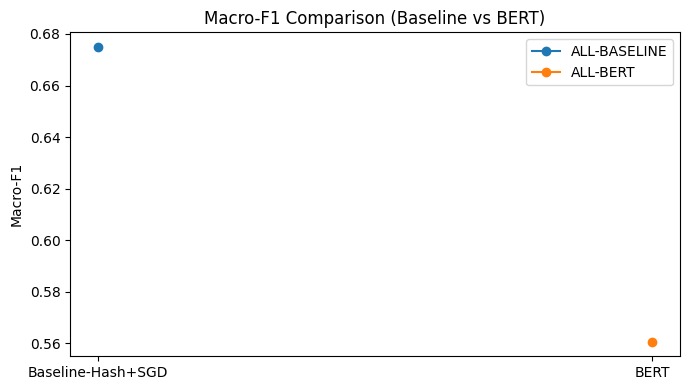

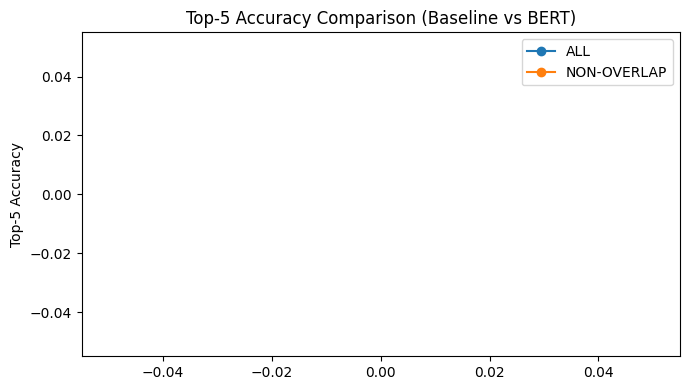

In [49]:
plot_df = cmp[(cmp["split"].isin(["ALL-BASELINE", "ALL-BERT"]))].copy()

# Macro-F1 plot
plt.figure(figsize=(7,4))
for split in ["ALL-BASELINE", "ALL-BERT"]:
    sub = plot_df[plot_df["split"]==split]
    plt.plot(sub["model"], sub["macro_f1"], marker="o", label=split)
plt.title("Macro-F1 Comparison (Baseline vs BERT)")
plt.ylabel("Macro-F1")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

# Top-5 plot (if available)
plt.figure(figsize=(7,4))
for split in ["ALL", "NON-OVERLAP"]:
    sub = plot_df[plot_df["split"]==split]
    plt.plot(sub["model"], sub["top5_acc"], marker="o", label=split)
plt.title("Top-5 Accuracy Comparison (Baseline vs BERT)")
plt.ylabel("Top-5 Accuracy")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
def top_confusions(df, pred_col, min_true=50, topn=25):
    tmp = df.copy()
    tmp["true"] = tmp[TRUE_COL].astype(str)
    tmp["pred"] = tmp[pred_col].astype(str)

    pairs = (tmp.groupby(["true","pred"]).size().reset_index(name="cnt"))
    true_cnt = tmp["true"].value_counts().rename("true_cnt").reset_index().rename(columns={"index":"true"})
    pairs = pairs.merge(true_cnt, on="true", how="left")
    pairs["rate_of_true"] = pairs["cnt"] / pairs["true_cnt"]

    # exclude correct pairs
    pairs = pairs[pairs["true"] != pairs["pred"]]

    by_cnt = pairs.sort_values("cnt", ascending=False).head(topn)
    by_rate = pairs[pairs["true_cnt"] >= min_true].sort_values("rate_of_true", ascending=False).head(topn)
    return by_cnt, by_rate

base_cnt, base_rate = top_confusions(test_df, BASE_PRED_COL)
bert_cnt, bert_rate = top_confusions(test_df, "pred_category_bert")

print("Baseline - top confusions by COUNT")
display(base_cnt)
print("Baseline - top confusions by RATE")
display(base_rate)

print("BERT - top confusions by COUNT")
display(bert_cnt)
print("BERT - top confusions by RATE")
display(bert_rate)

Baseline - top confusions by COUNT


,true,pred,cnt,true_cnt,rate_of_true
13882,Klasik Ayakkabı,Casual Ayakkabı,1491,3181,0.468721
10828,Gümüş Küpe,Bijuteri Küpe,1149,5632,0.204013
3799,Bebek Takımları,Alt-Üst Takım,998,5090,0.196071
10784,Gümüş Kolye,Bijuteri Kolye,961,5870,0.163714
27742,Yazıcı Sarf Malzemeleri,"Kartuş, Toner & Drum",899,9456,0.095072
8281,El Çantası,Omuz Çantası,878,1741,0.504308
25827,Tesettür Elbise,Elbise,878,1500,0.585333
23868,Spor T-Shirt,T-Shirt,830,1492,0.556300
735,Alt-Üst Takım,Bebek Takımları,804,6441,0.124825
23812,Spor Sweatshirt,Sweatshirt,783,1002,0.781437


Baseline - top confusions by RATE


,true,pred,cnt,true_cnt,rate_of_true
5791,Büyük Beden Yelek,Yelek,89,90,0.988889
25854,Tesettür Etek,Etek,303,307,0.986971
14922,Kumaş Pantolon,Pantolon,123,125,0.984000
25874,Tesettür Hırka,Hırka,222,227,0.977974
24109,Stiletto,Klasik Topuklu Ayakkabı,200,206,0.970874
5684,Büyük Beden Etek,Etek,98,101,0.970297
3193,Battal Boy Nevresim,Çift Kişilik Nevresim,106,110,0.963636
25972,Tesettür Yelek,Yelek,146,152,0.960526
23765,Spor Pantolon,Pantolon,160,167,0.958084
23978,Spor Çorap,Çorap,305,323,0.944272


BERT - top confusions by COUNT


,true,pred,cnt,true_cnt,rate_of_true
1811,Bagaj Havuzu,Oto Paspasları,2512,2547,0.986258
11600,Klasik Ayakkabı,Casual Ayakkabı,1864,3181,0.585979
612,Alt-Üst Takım,Bebek Takımları,1403,6441,0.217823
18376,Saat Kordonu,Akıllı Saat Kordon,1100,1352,0.813609
9023,Gümüş Küpe,Bijuteri Küpe,1002,5632,0.177912
16065,Oto Stopları,Oto Lambası,935,1262,0.740887
21602,Tesettür Elbise,Elbise,900,1500,0.600000
4797,Büyük Beden Sweatshirt,Sweatshirt,891,906,0.983444
23147,Yazıcı Sarf Malzemeleri,"Kartuş, Toner & Drum",887,9456,0.093803
19918,Spor Sweatshirt,Sweatshirt,874,1002,0.872255


BERT - top confusions by RATE


,true,pred,cnt,true_cnt,rate_of_true
1690,Ağda Bandı,Ağda,67,67,1.000000
16556,Oyuncu Masaüstü Bilgisayarı,Masaüstü Bilgisayar,216,217,0.995392
12493,Kumaş Pantolon,Pantolon,124,125,0.992000
4724,Büyük Beden Etek,Etek,100,101,0.990099
21620,Tesettür Etek,Etek,303,307,0.986971
1811,Bagaj Havuzu,Oto Paspasları,2512,2547,0.986258
4797,Büyük Beden Sweatshirt,Sweatshirt,891,906,0.983444
2094,Balon Zinciri,Balon,330,336,0.982143
2675,Battal Boy Nevresim,Çift Kişilik Nevresim,108,110,0.981818
20168,Stiletto,Klasik Topuklu Ayakkabı,202,206,0.980583


In [51]:
# define correctness
test_df["base_ok"] = (test_df[BASE_PRED_COL].astype(str) == test_df[TRUE_COL].astype(str))
test_df["bert_ok"] = (test_df["pred_category_bert"].astype(str) == test_df[TRUE_COL].astype(str))

improve = test_df[(~test_df["base_ok"]) & (test_df["bert_ok"])].copy()
worsen  = test_df[(test_df["base_ok"]) & (~test_df["bert_ok"])].copy()

cols = [c for c in ["product_id","product_text","canon_text",TRUE_COL,BASE_PRED_COL,"pred_category_bert","pred_top5_bert","main_true","main_pred_baseline","main_pred_bert"] if c in test_df.columns]

print("BERT improves over baseline:", len(improve))
display(improve[cols].head(30))

print("BERT worse than baseline:", len(worsen))
display(worsen[cols].head(30))

BERT improves over baseline: 26809


,product_id,product_text,canon_text,category,pred_top1,pred_category_bert,pred_top5_bert,main_true,main_pred_baseline,main_pred_bert
63,182257283,Canlı Kırmızı Sukulentli (haworthia) Sevimli K...,canlı kırmızı sukulentli (haworthia) sevimli k...,Saksı,Peluş Oyuncaklar,Saksı,"[Saksı, Yapay & Kuru Çiçek, Kaktüs, Teraryum &...",Ev & Yaşam,Oyuncak,Ev & Yaşam
103,175568495,Emaye El Dekorlu Çukur Servis Tabağı 23cm Marb...,emaye el dekorlu çukur servis tabağı 23cm marb...,Servis Tabağı,Tabak,Servis Tabağı,"[Servis Tabağı, Tabak, Kayık Tabak, Pasta Sunu...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
148,43607419,Silindir Turkuaz Dogal Taş=pkt=100-grm.,silindir turkuaz dogal taş=pkt=100-grm.,Boncuk,Motosiklet Yedek Parçalar,Boncuk,"[Boncuk, Örgü İpi, Bitki ve Tohum, Dekoratif Ü...",Aksesuar,Otomotiv,Aksesuar
184,165848922,100 Ledli Yeşil Yılbaşı Ağacı Işığı Led Ampül,100 ledli yeşil yılbaşı ağacı işığı led ampül,Led Işık,Ampul,Led Işık,"[Led Işık, Yılbaşı Süsleri, Ampul, Dekoratif A...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
257,103154270,Kız Bebek Beyaz Bej Yazlık Takım,kız bebek beyaz bej yazlık takım,Bebek Takımları,Alt-Üst Takım,Bebek Takımları,"[Bebek Takımları, Alt-Üst Takım, Tesettür Alt-...",Anne & Bebek,Giyim,Anne & Bebek
292,35166974,Malavi Gönder Bayrağı 70x105,malavi gönder bayrağı 70x105,Dosyalar,Ofis Sarf Tüketim Malzemeleri,Dosyalar,"[Dosyalar, Ofis Sarf Tüketim Malzemeleri, Foto...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
317,48065062,Unisex Bebek Bej Anasının Kuzusu Desenli Çıtçı...,unisex bebek bej anasının kuzusu desenli çıtçı...,Bebek Takımları,Alt-Üst Takım,Bebek Takımları,"[Bebek Takımları, Alt-Üst Takım, Tesettür Alt-...",Anne & Bebek,Giyim,Anne & Bebek
337,72813243,Alaska Bere & Boyunluk Yaban Yeşil (haki),alaska bere & boyunluk yaban yeşil (haki),Bere,Boyunluk,Bere,"[Bere, Boyunluk, Şapka, Tesettür Bone, Saç Bon...",Aksesuar,Aksesuar,Aksesuar
342,166790190,Opel Astra K Hb 2023 Model 4d Havuzlu Paspas,opel astra k hb 2023 model 4d havuzlu paspas,Oto Paspasları,Kapı Önü Paspası,Oto Paspasları,"[Oto Paspasları, Bagaj Havuzu, Kapı Önü Paspas...",Otomotiv,Ev & Yaşam,Otomotiv
365,141649542,Nenuco Uyku Arkadaşım 700014485,nenuco uyku arkadaşım 700014485,Model Bebek,Uyku Arkadaşları,Model Bebek,"[Model Bebek, Peluş Oyuncaklar, Eğitici Oyunca...",Oyuncak,Oyuncak,Oyuncak


BERT worse than baseline: 44394


,product_id,product_text,canon_text,category,pred_top1,pred_category_bert,pred_top5_bert,main_true,main_pred_baseline,main_pred_bert
33,98171395,Hindistan Cevizi Yağı Soguk Sıkım 250 Gr 2 Adet,hindistan cevizi yağı soguk sıkım 250 gr 2 adet,Hindistan Cevizi Yağı,Hindistan Cevizi Yağı,Bakım Yağı,"[Bakım Yağı, Gurme & Organik Ürünler, Pekmez, ...",Kozmetik,Kozmetik,Kozmetik
75,40616423,Bebek Temizleme Pamuğu 240 Adet (4pk*60),bebek temizleme pamuğu 240 adet (4pk*60),Pamuk ve Kulak Çubuğu,Pamuk ve Kulak Çubuğu,Bebek Islak Mendil,"[Bebek Islak Mendil, Islak Mendil, Temizlik Be...",Kozmetik,Kozmetik,Anne & Bebek
124,118848456,Hyundaı Elantra Sağ Stop Lambası 2002-2003 Ara...,hyundaı elantra sağ stop lambası 2002-2003 ara...,Oto Stopları,Oto Stopları,Oto Lambası,"[Oto Lambası, Oto Stopları, Oto Krom Aksesuar,...",Otomotiv,Otomotiv,Otomotiv
167,62873924,Aliş Oyuncak Kumandalı Turbo Coupe Akülü Araba...,aliş oyuncak kumandalı turbo coupe akülü araba...,Akülü Araçlar,Akülü Araçlar,Kumandalı Oyuncaklar,"[Kumandalı Oyuncaklar, Akülü Araçlar, Su Arıtm...",Oyuncak,Oyuncak,Oyuncak
171,51245309,Silecek Supurgesi 480 Mm-,silecek supurgesi 480 mm-,Silecekler & Aksesuarları,Silecekler & Aksesuarları,Süpürge Aksesuarı,"[Süpürge Aksesuarı, Paspas ve Mop, Beyaz Eşya ...",Otomotiv,Otomotiv,Ev & Yaşam
180,199358136,Kedi Ödül Çubuğu Sticks Somon Morina 20gr,kedi ödül çubuğu sticks somon morina 20gr,Kedi Ödülü,Kedi Ödülü,Köpek Ödülü,"[Köpek Ödülü, Kedi Ödülü, Kuş Yemi, Kedi Konse...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
190,178795006,Şeftali Ortam Kokusu 6'lı,şeftali ortam kokusu 6'lı,Oto Kokuları,Oto Kokuları,Koku Giderici ve Hava Temizleyici,"[Koku Giderici ve Hava Temizleyici, Oto Kokula...",Otomotiv,Otomotiv,Ev & Yaşam
197,202281870,El Çantası Organizer Telefon Şarj Aleti Ve Aks...,el çantası organizer telefon şarj aleti ve aks...,El Çantası,El Çantası,Masaüstü Organizer,"[Masaüstü Organizer, Araç İçi Telefon Tutucu, ...",Aksesuar,Aksesuar,Ev & Yaşam
204,36465481,"Su Basınç Regülatörü 2"" Inç","su basınç regülatörü 2"" inç",Banyo Tesisatı,Banyo Tesisatı,Beyaz Eşya Yedek Parça,"[Beyaz Eşya Yedek Parça, Banyo Tesisatı, Ölçüm...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
211,42333147,Stevia Tatlandırıcı Toz Şeker 3 X 400 G Prebiy...,stevia tatlandırıcı toz şeker 3 x 400 g prebiy...,Tatlandırıcı,Tatlandırıcı,Şekerleme,"[Şekerleme, Gurme & Organik Ürünler, Glutensiz...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam


In [52]:
import joblib
from pathlib import Path
import json

SAVE_DIR = Path("saved_models/baseline_hash_sgd")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# baseline objects expected in memory: clf, le, and your vectorizer params (we can recreate HashingVectorizer from params)
joblib.dump(clf, SAVE_DIR / "sgd_clf.joblib")
joblib.dump(le,  SAVE_DIR / "label_encoder.joblib")

# store the hashing config so you can rebuild the exact same feature transform later
baseline_config = {
    "word_vec": {
        "n_features": 2**19, "alternate_sign": False, "norm": "l2",
        "analyzer": "word", "ngram_range": [1,2], "lowercase": False
    },
    "char_vec": {
        "n_features": 2**18, "alternate_sign": False, "norm": "l2",
        "analyzer": "char_wb", "ngram_range": [3,5], "lowercase": False
    },
    "text_col_used": TEXT_COL if "TEXT_COL" in globals() else None
}

with open(SAVE_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(baseline_config, f, ensure_ascii=False, indent=2)

print("Saved baseline to:", SAVE_DIR)

Saved baseline to: saved_models/baseline_hash_sgd


In [53]:
from pathlib import Path
import json

BERT_DIR = Path("saved_models/bert_model")
BERT_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(BERT_DIR))      # saves model + config
tokenizer.save_pretrained(str(BERT_DIR))

# also save label mapping if you have it in memory
if "label2id" in globals():
    with open(BERT_DIR / "label2id.json", "w", encoding="utf-8") as f:
        json.dump(label2id, f, ensure_ascii=False, indent=2)
if "id2label" in globals():
    with open(BERT_DIR / "id2label.json", "w", encoding="utf-8") as f:
        json.dump({str(k): v for k, v in id2label.items()}, f, ensure_ascii=False, indent=2)

print("Saved BERT to:", BERT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BERT to: saved_models/bert_model


In [54]:
import json
category_mapping = json.load(open('category_map.json', 'r', encoding='utf-8'))


# MAIN CATEGORY + CATEGORY

In [2]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

train_df = pd.read_csv("preprocessed_train_final.csv")
test_df  = pd.read_csv("preprocessed_test_final.csv")
test_df = test_df.dropna(subset="category").reset_index(drop=True)



/tmp/ipykernel_21302/587949601.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df  = pd.read_csv("preprocessed_test_final.csv")


In [3]:
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- columns ---
TEXT_COL = "text_for_model"  # or "text_for_model"
LEAF_TRAIN_COL = "category_fixed" 
LEAF_TEST_COL  = "category"

import json
category_mapping = json.load(open('category_map.json', 'r', encoding='utf-8'))


if "sample_weight" not in train_df.columns:
    train_df["sample_weight"] = 1.0

# main labels
train_df["main_true"] = train_df[LEAF_TRAIN_COL].astype(str).map(category_mapping).fillna("Diğer")
test_df["main_true"]  = test_df[LEAF_TEST_COL].astype(str).map(category_mapping).fillna("Diğer")

# hashing text (if not already created)
def to_hash_text(s: pd.Series) -> pd.Series:
    return (s.fillna("").astype(str).str.lower()
              .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

if "hash_text" not in train_df.columns:
    train_df["hash_text"] = to_hash_text(train_df[TEXT_COL])
if "hash_text" not in test_df.columns:
    test_df["hash_text"]  = to_hash_text(test_df[TEXT_COL])

# vectorizers
word_vec = HashingVectorizer(n_features=2**19, alternate_sign=False, norm="l2",
                             analyzer="word", ngram_range=(1,2), lowercase=False)
char_vec = HashingVectorizer(n_features=2**18, alternate_sign=False, norm="l2",
                             analyzer="char_wb", ngram_range=(3,5), lowercase=False)

def X_text(text_series: pd.Series):
    return hstack([word_vec.transform(text_series), char_vec.transform(text_series)], format="csr")

# stage-1 label encoding
le_main = LabelEncoder()
y_main = le_main.fit_transform(train_df["main_true"].values)
n_main = len(le_main.classes_)
print("Main classes:", n_main, le_main.classes_)

clf_main = SGDClassifier(loss="log_loss", alpha=5e-6, penalty="l2",
                         max_iter=15, n_jobs=-1, random_state=42, average=True)

clf_main.fit(X_text(train_df["hash_text"]), y_main,
             sample_weight=train_df["sample_weight"].values.astype(np.float32))

# stage-1 test metrics
test_main_pred = le_main.inverse_transform(clf_main.predict(X_text(test_df["hash_text"])))
test_df["main_pred_top1"] = test_main_pred

print("MAIN test acc:", accuracy_score(test_df["main_true"], test_df["main_pred_top1"]))
print("MAIN test macroF1:", f1_score(test_df["main_true"], test_df["main_pred_top1"], average="macro"))

Main classes: 10 ['Aksesuar' 'Anne & Bebek' 'Ayakkabı' 'Elektronik' 'Ev & Yaşam' 'Giyim'
 'Kozmetik' 'Otomotiv' 'Oyuncak' 'Spor']
MAIN test acc: 0.9575390548166453
MAIN test macroF1: 0.9264825345590202


In [4]:
import numpy as np
from tqdm.auto import tqdm

def top2_main_labels_and_scores(text_series, batch=50_000):
    N = len(text_series)
    top1_lab = np.empty(N, dtype=object)
    top2_lab = np.empty(N, dtype=object)
    top1_scr = np.empty(N, dtype=np.float32)
    top2_scr = np.empty(N, dtype=np.float32)

    classes = le_main.classes_

    for start in tqdm(range(0, N, batch), desc="Top-2 main scoring"):
        end = min(start+batch, N)
        Xb = X_text(text_series.iloc[start:end])
        S = clf_main.decision_function(Xb)
        if S.ndim == 1:
            S = np.vstack([-S, S]).T

        # top2 indices (unsorted)
        idx2 = np.argpartition(-S, kth=1, axis=1)[:, :2]
        scr2 = S[np.arange(end-start)[:, None], idx2]

        # sort top2
        order = np.argsort(-scr2, axis=1)
        idx2s = idx2[np.arange(end-start)[:, None], order]
        scr2s = scr2[np.arange(end-start)[:, None], order]

        top1_lab[start:end] = classes[idx2s[:, 0]]
        top2_lab[start:end] = classes[idx2s[:, 1]]
        top1_scr[start:end] = scr2s[:, 0].astype(np.float32)
        top2_scr[start:end] = scr2s[:, 1].astype(np.float32)

    return top1_lab, top2_lab, top1_scr, top2_scr

# compute for train + test (uses predicted mains on train too, to match inference-time feature)
train_m1, train_m2, train_s1, train_s2 = top2_main_labels_and_scores(train_df["hash_text"], batch=80_000)
test_m1,  test_m2,  test_s1,  test_s2  = top2_main_labels_and_scores(test_df["hash_text"],  batch=80_000)

train_df["main_pred1"] = train_m1
train_df["main_pred2"] = train_m2
train_df["main_score1"] = train_s1
train_df["main_score2"] = train_s2

test_df["main_pred1"] = test_m1
test_df["main_pred2"] = test_m2
test_df["main_score1"] = test_s1
test_df["main_score2"] = test_s2

display(test_df[["main_pred1","main_pred2","main_score1","main_score2"]].head(10))

Top-2 main scoring:   0%|          | 0/36 [00:00<?, ?it/s]

Top-2 main scoring:   0%|          | 0/14 [00:00<?, ?it/s]

,main_pred1,main_pred2,main_score1,main_score2
0,Ayakkabı,Ev & Yaşam,5.126174,-4.057461
1,Giyim,Aksesuar,3.786836,-1.960095
2,Ev & Yaşam,Aksesuar,0.395941,-4.397385
3,Giyim,Ev & Yaşam,5.443670,-5.636611
4,Aksesuar,Ev & Yaşam,2.683652,-2.289914
5,Aksesuar,Giyim,5.044540,-4.471094
6,Ev & Yaşam,Kozmetik,6.020544,-4.956824
7,Anne & Bebek,Kozmetik,2.007252,-3.288017
8,Ev & Yaşam,Aksesuar,0.944920,-2.827832
9,Otomotiv,Elektronik,2.758627,-2.811192


In [5]:
train_df["hash_text_plus_main2"] = (
    train_df["hash_text"] +
    " __MAIN1__=" + train_df["main_pred1"].astype(str) +
    " __MAIN2__=" + train_df["main_pred2"].astype(str)
)
test_df["hash_text_plus_main2"] = (
    test_df["hash_text"] +
    " __MAIN1__=" + test_df["main_pred1"].astype(str) +
    " __MAIN2__=" + test_df["main_pred2"].astype(str)
)

In [6]:
def X_text_plus_scores(text_series, s1, s2):
    Xtxt = X_text(text_series)
    Xnum = csr_matrix(np.vstack([s1, s2]).T.astype(np.float32))
    return hstack([Xtxt, Xnum], format="csr")

# Choose which to use later:
USE_SCORES = True

In [7]:
# label encode leaf
le_leaf = LabelEncoder()
y_leaf = le_leaf.fit_transform(train_df[LEAF_TRAIN_COL].astype(str).values)
print("Leaf classes:", len(le_leaf.classes_))

clf_leaf = SGDClassifier(
    loss="log_loss",
    alpha=3e-6,
    penalty="l2",
    max_iter=5,
    n_jobs=-1,
    random_state=42,
    average=True
)

if USE_SCORES:
    X_leaf_train = X_text_plus_scores(train_df["hash_text_plus_main2"],
                                      train_df["main_score1"].values,
                                      train_df["main_score2"].values)
else:
    X_leaf_train = X_text(train_df["hash_text_plus_main2"])

clf_leaf.fit(X_leaf_train, y_leaf, sample_weight=train_df["sample_weight"].values.astype(np.float32))

print("Trained leaf model with TOP-2 main features.")

Leaf classes: 1140
Trained leaf model with TOP-2 main features.


/opt/app-root/lib64/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [8]:
if USE_SCORES:
    X_leaf_test = X_text_plus_scores(test_df["hash_text_plus_main2"],
                                     test_df["main_score1"].values,
                                     test_df["main_score2"].values)
else:
    X_leaf_test = X_text(test_df["hash_text_plus_main2"])

pred_leaf_id = clf_leaf.predict(X_leaf_test)
test_df["pred_leaf_2stage_top2"] = le_leaf.inverse_transform(pred_leaf_id)

yt = test_df[LEAF_TEST_COL].astype(str).values
yp = test_df["pred_leaf_2stage_top2"].astype(str).values

acc = accuracy_score(yt, yp)
mac = f1_score(yt, yp, average="macro")
mic = f1_score(yt, yp, average="micro")
w_f = f1_score(yt, yp, average="weighted")

print(f"LEAF TEST (top-2 main features) | acc={acc:.4f} | macroF1={mac:.4f} | microF1={mic:.4f} | weightedF1={w_f:.4f}")

# conditional leaf acc if main_true is in top-2 predicted mains
main_in_top2 = (test_df["main_true"] == test_df["main_pred1"]) | (test_df["main_true"] == test_df["main_pred2"])
acc_cond = accuracy_score(test_df.loc[main_in_top2, LEAF_TEST_COL], test_df.loc[main_in_top2, "pred_leaf_2stage_top2"])
print(f"LEAF acc | given main_true in top-2: {acc_cond:.4f} (n={main_in_top2.sum()})")

LEAF TEST (top-2 main features) | acc=0.8268 | macroF1=0.6570 | microF1=0.8268 | weightedF1=0.8158
LEAF acc | given main_true in top-2: 0.8355 (n=1071340)


In [9]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

def eval_leaf_topk_consistent(
    df: pd.DataFrame,
    k_list=(1,3,5),
    batch_size=50_000,
    mask=None,
    verbose=True,
):
    """
    Computes Top-k accuracy (k in k_list) + Top-1 F1s.
    Uses SAME feature construction as your training:
      - if USE_SCORES: X_text_plus_scores(text, main_score1, main_score2)
      - else: X_text(text)
    """
    if mask is None:
        mask = np.ones(len(df), dtype=bool)

    sub = df.loc[mask].copy()

    # --- true labels -> ids (safe)
    class_to_id = {c:i for i,c in enumerate(le_leaf.classes_)}
    y_true_str = sub[LEAF_TEST_COL].astype(str).values
    y_true_id = np.array([class_to_id.get(c, -1) for c in y_true_str], dtype=np.int32)

    valid = y_true_id >= 0
    sub = sub.iloc[valid].reset_index(drop=True)
    y_true_id = y_true_id[valid]

    n = len(sub)
    if n == 0:
        return {"n": 0}

    # --- counters
    hits = {k: 0 for k in k_list}
    pred_top1 = np.empty(n, dtype=np.int32)

    # prefetch numeric arrays once (faster)
    if USE_SCORES:
        s1 = sub["main_score1"].values.astype(np.float32)
        s2 = sub["main_score2"].values.astype(np.float32)

    for start in tqdm(range(0, n, batch_size), desc="Leaf Top-k eval"):
        end = min(start + batch_size, n)

        # build features EXACTLY like training
        if USE_SCORES:
            Xb = X_text_plus_scores(sub["hash_text_plus_main2"].iloc[start:end], s1[start:end], s2[start:end])
        else:
            Xb = X_text(sub["hash_text_plus_main2"].iloc[start:end])

        S = clf_leaf.decision_function(Xb)
        if S.ndim == 1:
            # binary edge case
            S = np.vstack([-S, S]).T

        yb = y_true_id[start:end]

        # top-1
        p1 = S.argmax(axis=1).astype(np.int32)
        pred_top1[start:end] = p1
        if 1 in hits:
            hits[1] += int((p1 == yb).sum())

        # top-k
        for k in k_list:
            if k == 1:
                continue
            kk = min(k, S.shape[1])
            idx = np.argpartition(-S, kth=kk-1, axis=1)[:, :kk]
            hits[k] += int(np.any(idx == yb[:, None], axis=1).sum())

    # --- build metrics
    out = {
        "n": int(n),
        "top1_acc": hits.get(1, np.nan) / n if 1 in hits else np.nan,
        "macro_f1": f1_score(y_true_id, pred_top1, average="macro"),
        "micro_f1": f1_score(y_true_id, pred_top1, average="micro"),
        "weighted_f1": f1_score(y_true_id, pred_top1, average="weighted"),
    }
    for k in k_list:
        out[f"top{k}_acc"] = hits[k] / n

    if verbose:
        print(out)

    return out

In [ ]:
mask_all = np.ones(len(test_df), dtype=bool)

if "is_exact_leak" in test_df.columns:
    mask_ov = test_df["is_exact_leak"].values
    mask_no = ~mask_ov
else:
    mask_ov = None
    mask_no = None

res_all = eval_leaf_topk_consistent(test_df, k_list=(1,3,5), mask=mask_all, batch_size=50_000, verbose=False)

rows = [{"split":"ALL", **res_all}]
if mask_ov is not None:
    res_ov = eval_leaf_topk_consistent(test_df, k_list=(1,3,5), mask=mask_ov, batch_size=50_000, verbose=False)
    res_no = eval_leaf_topk_consistent(test_df, k_list=(1,3,5), mask=mask_no, batch_size=50_000, verbose=False)
    rows += [{"split":"OVERLAP", **res_ov}, {"split":"NON-OVERLAP", **res_no}]

metrics_topk = pd.DataFrame(rows)
display(metrics_topk)

Leaf Top-k eval:   0%|          | 0/22 [00:00<?, ?it/s]

Leaf Top-k eval:   0%|          | 0/22 [00:00<?, ?it/s]

In [ ]:
def show_topk_examples(df, n=15, k=5, seed=42):
    samp = df.sample(n=min(n, len(df)), random_state=seed).copy().reset_index(drop=True)

    if USE_SCORES:
        Xb = X_text_plus_scores(samp["hash_text_plus_main2"], 
                                samp["main_score1"].values.astype(np.float32), 
                                samp["main_score2"].values.astype(np.float32))
    else:
        Xb = X_text(samp["hash_text_plus_main2"])

    S = clf_leaf.decision_function(Xb)
    if S.ndim == 1:
        S = np.vstack([-S, S]).T

    kk = min(k, S.shape[1])
    idx = np.argpartition(-S, kth=kk-1, axis=1)[:, :kk]
    scr = S[np.arange(len(samp))[:, None], idx]
    order = np.argsort(-scr, axis=1)
    idx = idx[np.arange(len(samp))[:, None], order]

    topk_labels = [[le_leaf.classes_[int(j)] for j in row] for row in idx]

    out = samp[[TEXT_COL, LEAF_TEST_COL, "main_pred1", "main_pred2"]].copy()
    out["top5_pred"] = topk_labels
    display(out)

show_topk_examples(test_df, n=20, k=5)

In [19]:
show_topk_examples(test_df, n=20, k=5)

,text_for_model,category,main_pred1,main_pred2,top5_pred
0,trident a5 uyumlu hi fi superior ses kalitesi ...,Kulak içi TWS Bluetooth Kulaklık,Elektronik,Ev & Yaşam,"[Kulak içi TWS Bluetooth Kulaklık, Kulak üstü ..."
1,420835 bardak 390 cc soğuk kesme veneto 6 adet,Bardak,Ev & Yaşam,Kozmetik,"[Bardak, Vida, Çivi & Dübel, Kutu ve Ambalaj M..."
2,opel 302 full boya seti,Oto Boya,Otomotiv,Ev & Yaşam,"[Oto Boya, Otomobil Yedek Parçalar, Lastik, Ot..."
3,silva asma klozet parlak kırmızı soft kapak a0...,Klozet,Ev & Yaşam,Aksesuar,"[Klozet, Klozet Kapağı, Köpek Tasması, Dosyala..."
4,etkileyici klasik şam tasarım duvar kağıdı ile...,Duvar Kağıdı,Ev & Yaşam,Giyim,"[Duvar Kağıdı, Duvar & Cephe Kaplama, Duvar Ör..."
5,1981 model mercedes 126 için tavan araç üstü p...,Bagaj Düzenleyici,Otomotiv,Elektronik,"[Bagaj Düzenleyici, Oto Krom Aksesuar, Direksi..."
6,lenovo a6000 plus kulak içi kulaklık 3 5mm ly800,Kulak İçi Kablolu Kulaklık,Elektronik,Ev & Yaşam,"[Kulak İçi Kablolu Kulaklık, Bilgisayar Yedek ..."
7,erkek güneş gözlüğü tl509 c51,Güneş Gözlüğü,Aksesuar,Giyim,"[Güneş Gözlüğü, Kemer, Kravat, Rozet, Şapka]"
8,real thing shad 11cm 4 pcs renk blue back herr...,Suni Yem,Spor,Elektronik,"[Suni Yem, Olta Kamışı, Olta Misinası, Silikon..."
9,opticapilaril spf15 intensive eye cream15 ml,Göz Kremi,Kozmetik,Ev & Yaşam,"[Yüz Kremi, Göz Kremi, Parfüm, Vücut Kremi, Ba..."


# BERT -> MAIN + CATEGORY

In [32]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [33]:
TEXT_COL = "text_for_model"  # <-- change if needed
LEAF_TRAIN_COL = "category_fixed" if "category_fixed" in train_df.columns else "category"
LEAF_TEST_COL  = "category_fixed" if "category_fixed" in test_df.columns else "category"

# sample_weight optional
if "sample_weight" not in train_df.columns:
    train_df["sample_weight"] = 1.0
if "sample_weight" not in test_df.columns:
    test_df["sample_weight"] = 1.0

# main labels from leaf
train_df["main_true"] = train_df[LEAF_TRAIN_COL].astype(str).map(category_mapping).fillna("Diğer")
test_df["main_true"]  = test_df[LEAF_TEST_COL].astype(str).map(category_mapping).fillna("Diğer")

print("Train:", train_df.shape, "| Test:", test_df.shape)
print("Leaf:", LEAF_TRAIN_COL, LEAF_TEST_COL)
train_df[[TEXT_COL, LEAF_TRAIN_COL, "main_true", "sample_weight"]].head()

Train: (2872653, 42) | Test: (1082901, 21)
Leaf: category_fixed category


,text_for_model,category_fixed,main_true,sample_weight
0,deniz feneri iskele kanvas tablo 180x60cm,Tablo,Ev & Yaşam,1.0
1,opel corsa serisi silver gold model ön arka ot...,Oto Koltuk Kılıfı,Otomotiv,1.0
2,ilk kitaplarım şekiller,Bebek & Aktivite Oyuncakları,Oyuncak,0.3
3,yeşil nokta desen mendilli klasik kravat kk10027,Kravat,Aksesuar,1.0
4,mor zeminde pembe yuvarlak desenli dekoratif t...,Fon Perde,Ev & Yaşam,1.0


In [34]:
def topk_idx_from_logits(logits: np.ndarray, k: int) -> np.ndarray:
    # logits: (N, C)
    idx = np.argpartition(-logits, kth=k-1, axis=1)[:, :k]
    row = np.arange(logits.shape[0])[:, None]
    idx_sorted = idx[row, np.argsort(-logits[row, idx], axis=1)]
    return idx_sorted

def topk_accuracy(y_true: np.ndarray, topk_idx: np.ndarray) -> float:
    # topk_idx: (N, k)
    return float(np.mean([y_true[i] in topk_idx[i] for i in range(len(y_true))]))

def compute_leaf_metrics_from_logits(logits: np.ndarray, y_true: np.ndarray) -> dict:
    pred = np.argmax(logits, axis=1)
    top3 = topk_idx_from_logits(logits, 3)
    top5 = topk_idx_from_logits(logits, 5)
    return {
        "acc": float(accuracy_score(y_true, pred)),
        "macro_f1": float(f1_score(y_true, pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, pred, average="weighted")),
        "top3_acc": float(topk_accuracy(y_true, top3)),
        "top5_acc": float(topk_accuracy(y_true, top5)),
    }

In [35]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        weights = inputs.get("sample_weight", None)

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            token_type_ids=inputs.get("token_type_ids", None),
            labels=None
        )
        logits = outputs.logits
        loss_vec = torch.nn.functional.cross_entropy(logits, labels, reduction="none")

        if weights is not None:
            weights = weights.to(loss_vec.dtype)
            loss = (loss_vec * weights).mean()
        else:
            loss = loss_vec.mean()

        return (loss, outputs) if return_outputs else loss

In [36]:
def make_hf_dataset(df: pd.DataFrame, text_col: str, label_col: str, label2id: dict, tokenizer, max_len: int):
    tmp = df[[text_col, label_col, "sample_weight"]].copy()
    tmp[text_col] = tmp[text_col].fillna("").astype(str)
    tmp["label"] = tmp[label_col].astype(str).map(label2id).astype(int)

    ds = Dataset.from_pandas(tmp[[text_col, "label", "sample_weight"]], preserve_index=False)

    def tok(batch):
        return tokenizer(batch[text_col], truncation=True, padding="max_length", max_length=max_len)

    ds = ds.map(tok, batched=True, remove_columns=[text_col])
    ds.set_format(type="torch")
    return ds

In [40]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
from typing import Dict

def compute_metrics_fn(eval_pred) -> Dict[str, float]:
    """
    eval_pred is a transformers.EvalPrediction
    with attributes: predictions (np.ndarray) and label_ids (np.ndarray)
    predictions: shape (N, num_labels) for sequence classification (logits)
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):  # some models return a tuple
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)

    out = {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "micro_f1": f1_score(labels, preds, average="micro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }
    return out

In [41]:
torch.backends.cuda.matmul.allow_tf32 = True

BASE_MODEL = "Trendyol/tyroberta"  # good for TR+EN mix
tokenizer_main = AutoTokenizer.from_pretrained(BASE_MODEL)

# label encoders for main
main_labels = sorted(train_df["main_true"].unique().tolist())
main_le = LabelEncoder().fit(main_labels)

main_id2label = {i: lab for i, lab in enumerate(main_le.classes_)}
main_label2id = {lab: i for i, lab in enumerate(main_le.classes_)}

# build datasets
MAX_LEN_MAIN = 96
ds_main_train = make_hf_dataset(
    train_df, TEXT_COL, "main_true", main_label2id, tokenizer_main, MAX_LEN_MAIN
)
ds_main_test = make_hf_dataset(
    test_df, TEXT_COL, "main_true", main_label2id, tokenizer_main, MAX_LEN_MAIN
)

model_main = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(main_label2id),
    id2label=main_id2label,
    label2id=main_label2id
)

args_main = TrainingArguments(
    output_dir="bert_stage1_main",
    # train
    num_train_epochs=1,
    max_steps=10_000,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,

    per_device_train_batch_size=128,     # A100 20GB + MAX_LEN=64 usually OK
    per_device_eval_batch_size=128,
    gradient_accumulation_steps=1,

    bf16=True,                          # A100 supports bf16 well
    fp16=False,

    eval_strategy="steps",
    eval_steps=5000,
    logging_steps=200,
    save_steps=5000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none",                   # change to "tensorboard" if you want
)

trainer_main = WeightedTrainer(
    model=model_main,
    args=args_main,
    train_dataset=ds_main_train,
    eval_dataset=ds_main_test,
    processing_class=tokenizer_main,
    compute_metrics=compute_metrics_fn
)

trainer_main.train()
pred_main = trainer_main.predict(ds_main_test)
main_logits_test = pred_main.predictions
y_main_test = pred_main.label_ids

# main metrics (Top-1 + macroF1)
main_pred = np.argmax(main_logits_test, axis=1)
print("MAIN acc:", accuracy_score(y_main_test, main_pred))
print("MAIN macroF1:", f1_score(y_main_test, main_pred, average="macro"))

Map:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Map:   0%|          | 0/1082901 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Trendyol/tyroberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1,Weighted F1
5000,0.126167,0.088987,0.973233,0.949382,0.973233,0.973067
10000,0.097263,0.077018,0.976908,0.955599,0.976908,0.976838


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

MAIN acc: 0.976908323106175
MAIN macroF1: 0.9555991771092198


In [42]:
def predict_top2_main(trainer, ds):
    out = trainer.predict(ds)
    logits = out.predictions
    top2 = topk_idx_from_logits(logits, 2)
    top1_ids = top2[:, 0]
    top2_ids = top2[:, 1]

    # convert ids -> names
    top1_lab = np.array([main_id2label[i] for i in top1_ids], dtype=object)
    top2_lab = np.array([main_id2label[i] for i in top2_ids], dtype=object)

    # probs (optional)
    probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
    p1 = probs[np.arange(len(probs)), top1_ids].astype(np.float32)
    p2 = probs[np.arange(len(probs)), top2_ids].astype(np.float32)

    return top1_lab, top2_lab, p1, p2

# predict for train and test
train_main_top1, train_main_top2, train_p1, train_p2 = predict_top2_main(trainer_main, ds_main_train)
test_main_top1,  test_main_top2,  test_p1,  test_p2  = predict_top2_main(trainer_main, ds_main_test)

train_df["main_pred1"] = train_main_top1
train_df["main_pred2"] = train_main_top2
test_df["main_pred1"]  = test_main_top1
test_df["main_pred2"]  = test_main_top2

def add_main_tokens(df: pd.DataFrame, base_text_col: str) -> pd.Series:
    return (
        df[base_text_col].fillna("").astype(str)
        + " __MAIN1__ " + df["main_pred1"].astype(str)
        + " __MAIN2__ " + df["main_pred2"].astype(str)
    )

train_df["text_plus_main2"] = add_main_tokens(train_df, TEXT_COL)
test_df["text_plus_main2"]  = add_main_tokens(test_df, TEXT_COL)

train_df[["main_pred1","main_pred2","text_plus_main2"]].head(3)

,main_pred1,main_pred2,text_plus_main2
0,Ev & Yaşam,Oyuncak,deniz feneri iskele kanvas tablo 180x60cm __MA...
1,Otomotiv,Elektronik,opel corsa serisi silver gold model ön arka ot...
2,Oyuncak,Ev & Yaşam,ilk kitaplarım şekiller __MAIN1__ Oyuncak __MA...


In [43]:
# leaf labels
leaf_le = LabelEncoder()
leaf_le.fit(train_df[LEAF_TRAIN_COL].astype(str).values)

leaf_id2label = {i: lab for i, lab in enumerate(leaf_le.classes_)}
leaf_label2id = {lab: i for i, lab in enumerate(leaf_le.classes_)}

MAX_LEN_LEAF = 96  # usually enough for your title lengths + main tokens

tokenizer_leaf = AutoTokenizer.from_pretrained(BASE_MODEL)

# datasets for baseline (text only)
ds_leaf_train_base = make_hf_dataset(
    train_df, TEXT_COL, LEAF_TRAIN_COL, leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF
)
ds_leaf_test_base = make_hf_dataset(
    test_df, TEXT_COL, LEAF_TEST_COL, leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF
)

# datasets for main-augmented (text + __MAIN1__/__MAIN2__)
ds_leaf_train_main = make_hf_dataset(
    train_df, "text_plus_main2", LEAF_TRAIN_COL, leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF
)
ds_leaf_test_main = make_hf_dataset(
    test_df, "text_plus_main2", LEAF_TEST_COL, leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF
)

Map:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Map:   0%|          | 0/1082901 [00:00<?, ? examples/s]

Map:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Map:   0%|          | 0/1082901 [00:00<?, ? examples/s]

In [45]:
model_leaf_base = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(leaf_label2id),
    id2label=leaf_id2label,
    label2id=leaf_label2id
)

args_leaf = TrainingArguments(
    output_dir="bert_stage2_leaf_base",
    # train
    num_train_epochs=1,
    max_steps=10_000,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,

    per_device_train_batch_size=64,     # A100 20GB + MAX_LEN=64 usually OK
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,

    bf16=True,                          # A100 supports bf16 well
    fp16=False,

    eval_strategy="steps",
    eval_steps=5000,
    logging_steps=200,
    save_steps=5000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none",                   # change to "tensorboard" if you want
)

trainer_leaf_base = WeightedTrainer(
    model=model_leaf_base,
    args=args_leaf,
    train_dataset=ds_leaf_train_base,
    eval_dataset=ds_leaf_test_base,
    processing_class=tokenizer_main,
    compute_metrics=compute_metrics_fn
)

trainer_leaf_base.train()
pred_base = trainer_leaf_base.predict(ds_leaf_test_base)
metrics_base = compute_leaf_metrics_from_logits(pred_base.predictions, pred_base.label_ids)
metrics_base

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Trendyol/tyroberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1,Weighted F1
5000,1.135544,1.144506,0.793659,0.484033,0.793659,0.763872
10000,0.869991,0.949231,0.818045,0.559148,0.818045,0.795809


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'acc': 0.8180452322049754,
 'macro_f1': 0.5591484546432489,
 'weighted_f1': 0.7958088516909415,
 'top3_acc': 0.9188162168102163,
 'top5_acc': 0.9399363376707566}

In [46]:
model_leaf_main = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(leaf_label2id),
    id2label=leaf_id2label,
    label2id=leaf_label2id
)

args_leaf_main = TrainingArguments(
    output_dir="bert_stage2_leaf_with_main2",
    num_train_epochs=1,
    max_steps=10_000,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,

    per_device_train_batch_size=64,     # A100 20GB + MAX_LEN=64 usually OK
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,

    bf16=True,                          # A100 supports bf16 well
    fp16=False,

    eval_strategy="steps",
    eval_steps=5000,
    logging_steps=200,
    save_steps=5000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none",                   # change to "tensorboard" if you want
)

trainer_leaf_main = WeightedTrainer(
    model=model_leaf_main,
    args=args_leaf_main,
    train_dataset=ds_leaf_train_main,
    eval_dataset=ds_leaf_test_main,
    processing_class=tokenizer_main,
    compute_metrics=compute_metrics_fn
)

trainer_leaf_main.train()
pred_mainfeat = trainer_leaf_main.predict(ds_leaf_test_main)
metrics_mainfeat = compute_leaf_metrics_from_logits(pred_mainfeat.predictions, pred_mainfeat.label_ids)
metrics_mainfeat

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Trendyol/tyroberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1,Weighted F1
5000,1.029564,1.097378,0.803879,0.511213,0.803879,0.777114
10000,0.784978,0.923227,0.826227,0.588357,0.826227,0.806941


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'acc': 0.8262269588817445,
 'macro_f1': 0.5883572517735293,
 'weighted_f1': 0.8069405610550057,
 'top3_acc': 0.9232727645463435,
 'top5_acc': 0.9429079851251407}

In [47]:
compare = pd.DataFrame([
    {"model": "Leaf BERT (text only)", **metrics_base},
    {"model": "Leaf BERT (text + predicted MAIN top2)", **metrics_mainfeat},
]).set_index("model")

compare

,acc,macro_f1,weighted_f1,top3_acc,top5_acc
model,,,,,
Leaf BERT (text only),0.818045,0.559148,0.795809,0.918816,0.939936
Leaf BERT (text + predicted MAIN top2),0.826227,0.588357,0.806941,0.923273,0.942908


In [51]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

LEAF_TRAIN_COL = "category_fixed" if "category_fixed" in train_df.columns else "category"
LEAF_TEST_COL  = "category_fixed" if "category_fixed" in test_df.columns else "category"

# Baseline (SGD) prediction column you already have
SGD_PRED_COL = "pred_leaf_2stage_top2"
assert SGD_PRED_COL in test_df.columns, f"Missing {SGD_PRED_COL} in test_df"

# Try to auto-pick a BERT prediction column from test_df
bert_candidates = [c for c in test_df.columns if ("bert" in c.lower() or "transform" in c.lower()) and ("pred" in c.lower())]
print("BERT pred candidates:", bert_candidates)

# If auto-pick fails, set manually:

BERT_PRED_COL = bert_candidates[0] if len(bert_candidates) == 1 else None
BERT_PRED_COL = "pred_leaf_bert_main2_top1"
print("Auto-picked BERT_PRED_COL:", BERT_PRED_COL)

# If None, set it explicitly:
# BERT_PRED_COL = "pred_leaf_bert_main2_top1"  # <-- example
#assert BERT_PRED_COL in test_df.columns, "Set BERT_PRED_COL to your BERT prediction column name"

BERT pred candidates: []
Auto-picked BERT_PRED_COL: pred_leaf_bert_main2_top1


In [66]:
top1_ids = np.argmax(pred_mainfeat.predictions,axis=1).astype(int)
test_df["pred_leaf_bert_main2_top1"] = [leaf_id2label[i] for i in top1_ids]

In [56]:
# Train frequency (leaf)
train_freq = train_df[LEAF_TRAIN_COL].astype(str).value_counts()
freq_tbl = train_freq.rename("train_cnt").reset_index().rename(columns={"index": "leaf"})
freq_tbl["cum_cnt"] = freq_tbl["train_cnt"].cumsum()
freq_tbl["cum_share"] = freq_tbl["cum_cnt"] / freq_tbl["train_cnt"].sum()

def slice_name(cum_share):
    if cum_share <= 0.80:
        return "head"
    elif cum_share <= 0.95:
        return "body"
    else:
        return "tail"

freq_tbl["hbt"] = freq_tbl["cum_share"].map(slice_name)

hbt_map = dict(zip(freq_tbl["category_fixed"], freq_tbl["hbt"]))

freq_tbl.groupby("hbt").agg(
    n_labels=("category_fixed", "count"),
    train_rows=("train_cnt", "sum")
).assign(train_pct=lambda x: (x["train_rows"] / x["train_rows"].sum() * 100).round(2))

,n_labels,train_rows,train_pct
hbt,,,
body,353,431587,15.02
head,427,2297266,79.97
tail,360,143800,5.01


In [68]:
eval_df = test_df.copy()

eval_df["y_true"] = eval_df[LEAF_TEST_COL].astype(str)
eval_df["y_pred_sgd"] = eval_df[SGD_PRED_COL].astype(str)
eval_df["y_pred_bert"] = eval_df[BERT_PRED_COL].astype(str)

# Map to head/body/tail using train distribution
eval_df["hbt"] = eval_df["y_true"].map(hbt_map).fillna("tail")  # should not happen if no new labels

# Helpful counts
eval_df["hbt"].value_counts(normalize=True).mul(100).round(2)

hbt
head    82.02
body    12.55
tail     5.43
Name: proportion, dtype: float64

In [69]:
def metrics_block(df, y_pred_col):
    y_true = df["y_true"].values
    y_pred = df[y_pred_col].values

    return {
        "n_rows": int(len(df)),
        "n_labels": int(pd.Series(y_true).nunique()),
        "acc": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

rows = []
for part in ["head", "body", "tail", "ALL"]:
    sub = eval_df if part == "ALL" else eval_df[eval_df["hbt"] == part]

    rows.append({"slice": part, "model": "SGD",  **metrics_block(sub, "y_pred_sgd")})
    rows.append({"slice": part, "model": "BERT", **metrics_block(sub, "y_pred_bert")})

res = pd.DataFrame(rows)

# nicer formatting
for c in ["acc", "macro_f1", "weighted_f1"]:
    res[c] = res[c].round(4)

res.sort_values(["slice", "model"])

,slice,model,n_rows,n_labels,acc,macro_f1,weighted_f1
7,ALL,BERT,1082901,1140,0.8262,0.5884,0.8069
6,ALL,SGD,1082901,1140,0.8268,0.6570,0.8158
3,body,BERT,135933,353,0.6704,0.2910,0.7299
2,body,SGD,135933,353,0.6842,0.2826,0.7682
1,head,BERT,888204,427,0.8838,0.4129,0.8879
0,head,SGD,888204,427,0.8733,0.3660,0.8778
5,tail,BERT,58764,360,0.3165,0.0933,0.3505
4,tail,SGD,58764,360,0.4534,0.1507,0.5266


In [70]:
pivot = res.pivot(index="slice", columns="model", values=["acc","macro_f1","weighted_f1","n_rows","n_labels"])
display(pivot)

delta = pd.DataFrame({
    "acc_delta": (pivot["acc"]["BERT"] - pivot["acc"]["SGD"]).round(4),
    "macro_f1_delta": (pivot["macro_f1"]["BERT"] - pivot["macro_f1"]["SGD"]).round(4),
    "weighted_f1_delta": (pivot["weighted_f1"]["BERT"] - pivot["weighted_f1"]["SGD"]).round(4),
    "n_rows": pivot["n_rows"]["BERT"].astype(int),
    "n_labels": pivot["n_labels"]["BERT"].astype(int),
})
delta

acc         macro_f1         weighted_f1             n_rows  \
model    BERT     SGD     BERT     SGD        BERT     SGD       BERT   
slice                                                                   
ALL    0.8262  0.8268   0.5884  0.6570      0.8069  0.8158  1082901.0   
body   0.6704  0.6842   0.2910  0.2826      0.7299  0.7682   135933.0   
head   0.8838  0.8733   0.4129  0.3660      0.8879  0.8778   888204.0   
tail   0.3165  0.4534   0.0933  0.1507      0.3505  0.5266    58764.0   

                 n_labels          
model        SGD     BERT     SGD  
slice                              
ALL    1082901.0   1140.0  1140.0  
body    135933.0    353.0   353.0  
head    888204.0    427.0   427.0  
tail     58764.0    360.0   360.0

,acc_delta,macro_f1_delta,weighted_f1_delta,n_rows,n_labels
slice,,,,,
ALL,-0.0006,-0.0686,-0.0089,1082901,1140
body,-0.0138,0.0084,-0.0383,135933,353
head,0.0105,0.0469,0.0101,888204,427
tail,-0.1369,-0.0574,-0.1761,58764,360


# WEIGHTED BERT WITH MAIN + CATEGORY

In [4]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler

In [37]:
TEXT_COL = "text_for_model"  # <-- change if needed
LEAF_TRAIN_COL = "category_fixed" if "category_fixed" in train_df.columns else "category"
LEAF_TEST_COL  = "category_fixed" if "category_fixed" in test_df.columns else "category"

# per-row weights (optional)
if "sample_weight" not in train_df.columns:
    train_df["sample_weight"] = 1.0
if "sample_weight" not in test_df.columns:
    test_df["sample_weight"] = 1.0

# derive main labels from leaf (your mapping)
train_df["main_true"] = train_df[LEAF_TRAIN_COL].astype(str).map(category_mapping).fillna("Diğer")
test_df["main_true"]  = test_df[LEAF_TEST_COL].astype(str).map(category_mapping).fillna("Diğer")

print("Train:", train_df.shape, "| Test:", test_df.shape)
train_df[[TEXT_COL, LEAF_TRAIN_COL, "main_true", "sample_weight"]].head()

Train: (2872653, 42) | Test: (1082901, 19)


,text_for_model,category_fixed,main_true,sample_weight
0,deniz feneri iskele kanvas tablo 180x60cm,Tablo,Ev & Yaşam,1.0
1,opel corsa serisi silver gold model ön arka ot...,Oto Koltuk Kılıfı,Otomotiv,1.0
2,ilk kitaplarım şekiller,Bebek & Aktivite Oyuncakları,Oyuncak,0.3
3,yeşil nokta desen mendilli klasik kravat kk10027,Kravat,Aksesuar,1.0
4,mor zeminde pembe yuvarlak desenli dekoratif t...,Fon Perde,Ev & Yaşam,1.0


In [10]:
def topk_idx_from_logits(logits: np.ndarray, k: int) -> np.ndarray:
    idx = np.argpartition(-logits, kth=k-1, axis=1)[:, :k]
    row = np.arange(logits.shape[0])[:, None]
    idx_sorted = idx[row, np.argsort(-logits[row, idx], axis=1)]
    return idx_sorted

def topk_accuracy(y_true: np.ndarray, topk_idx: np.ndarray) -> float:
    return float(np.mean([y_true[i] in topk_idx[i] for i in range(len(y_true))]))

def metrics_from_logits(logits: np.ndarray, y_true: np.ndarray) -> dict:
    pred = np.argmax(logits, axis=1)
    top3 = topk_idx_from_logits(logits, 3)
    top5 = topk_idx_from_logits(logits, 5)
    return {
        "acc": float(accuracy_score(y_true, pred)),
        "macro_f1": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, pred, average="weighted", zero_division=0)),
        "top3_acc": float(topk_accuracy(y_true, top3)),
        "top5_acc": float(topk_accuracy(y_true, top5)),
    }

In [11]:
def build_label_maps(series: pd.Series):
    le = LabelEncoder()
    le.fit(series.astype(str).values)
    id2label = {i: lab for i, lab in enumerate(le.classes_)}
    label2id = {lab: i for i, lab in id2label.items()}
    return le, label2id, id2label

def make_hf_dataset(df: pd.DataFrame, text_col: str, label_col: str, label2id: dict, tokenizer, max_len: int):
    tmp = df[[text_col, label_col, "sample_weight"]].copy()
    tmp[text_col] = tmp[text_col].fillna("").astype(str)
    tmp["label"] = tmp[label_col].astype(str).map(label2id)

    # drop rows with unseen labels (shouldn't happen for your test, but safe)
    tmp = tmp.dropna(subset=["label"]).copy()
    tmp["label"] = tmp["label"].astype(int)

    ds = Dataset.from_pandas(tmp[[text_col, "label", "sample_weight"]], preserve_index=False)

    def tok(batch):
        return tokenizer(batch[text_col], truncation=True, padding="max_length", max_length=max_len)

    ds = ds.map(tok, batched=True, remove_columns=[text_col])
    ds = ds.rename_column("label", "labels")
    ds.set_format(type="torch")
    return ds

def compute_class_and_sampler_weights(labels_np: np.ndarray, sample_weight_np: np.ndarray, alpha: float = 0.5):
    """
    class_weight[label] = (1/freq)^alpha normalized to mean=1
    sampler_weight[i] = sample_weight[i] * class_weight[labels[i]]
    """
    labels_np = labels_np.astype(int)
    n_classes = int(labels_np.max()) + 1

    freq = np.bincount(labels_np, minlength=n_classes).astype(np.float64)
    freq = np.maximum(freq, 1.0)

    class_w = (1.0 / freq) ** alpha
    class_w = class_w / (class_w.mean() + 1e-12)  # normalize

    sampler_w = sample_weight_np.astype(np.float64) * class_w[labels_np]
    sampler_w = sampler_w / (sampler_w.mean() + 1e-12)

    return class_w.astype(np.float32), sampler_w.astype(np.float64)

In [12]:
class BalancedWeightedTrainer(Trainer):
    def __init__(self, *args, sampler_weights=None, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._sampler_weights = sampler_weights  # numpy float64 length N
        self._class_weights = class_weights      # numpy float32 length C

    def get_train_dataloader(self):
        if self.train_dataset is None:
            raise ValueError("Trainer: training requires a train_dataset.")

        data_collator = self.data_collator
        if data_collator is None:
            data_collator = DataCollatorWithPadding(self.tokenizer)

        # WeightedRandomSampler (balanced sampling)
        if self._sampler_weights is not None:
            w = torch.as_tensor(self._sampler_weights, dtype=torch.double)
            sampler = WeightedRandomSampler(
                weights=w,
                num_samples=len(w),      # keep epoch length ~dataset size
                replacement=True
            )
            return DataLoader(
                self.train_dataset,
                batch_size=self.args.train_batch_size,
                sampler=sampler,
                collate_fn=data_collator,
                num_workers=0,
                pin_memory=True
            )

        return super().get_train_dataloader()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        sample_w = inputs.get("sample_weight", None)

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            token_type_ids=inputs.get("token_type_ids", None),
            labels=None
        )
        logits = outputs.logits

        # per-example CE
        loss_vec = torch.nn.functional.cross_entropy(logits, labels, reduction="none")

        # class weights
        if self._class_weights is not None:
            cw = torch.tensor(self._class_weights, device=loss_vec.device, dtype=loss_vec.dtype)
            loss_vec = loss_vec * cw[labels]

        # sample weights
        if sample_w is not None:
            loss_vec = loss_vec * sample_w.to(loss_vec.dtype)

        loss = loss_vec.mean()
        return (loss, outputs) if return_outputs else loss

In [15]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
from typing import Dict

def compute_metrics_fn(eval_pred) -> Dict[str, float]:
    """
    eval_pred is a transformers.EvalPrediction
    with attributes: predictions (np.ndarray) and label_ids (np.ndarray)
    predictions: shape (N, num_labels) for sequence classification (logits)
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):  # some models return a tuple
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)

    out = {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "micro_f1": f1_score(labels, preds, average="micro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }
    return out

In [17]:
torch.backends.cuda.matmul.allow_tf32 = True

BASE_MODEL = "Trendyol/tyroberta"   # TR+EN mixed titles
MAX_LEN_MAIN = 96

tokenizer_main = AutoTokenizer.from_pretrained(BASE_MODEL)

# label space
main_le, main_label2id, main_id2label = build_label_maps(train_df["main_true"])

# datasets
ds_main_train = make_hf_dataset(train_df, TEXT_COL, "main_true", main_label2id, tokenizer_main, MAX_LEN_MAIN)
ds_main_test  = make_hf_dataset(test_df,  TEXT_COL, "main_true", main_label2id, tokenizer_main, MAX_LEN_MAIN)

# compute class weights + sampler weights for balanced sampling
y_main_train = np.array(ds_main_train["labels"])
sw_main_train = np.array(ds_main_train["sample_weight"], dtype=np.float32)
main_class_w, main_sampler_w = compute_class_and_sampler_weights(y_main_train, sw_main_train, alpha=0.5)

model_main = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(main_label2id),
    id2label=main_id2label,
    label2id=main_label2id
)

args_main = TrainingArguments(
    output_dir="bert_stage1_main_balanced",
    num_train_epochs=1,
    max_steps=10_000,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,

    per_device_train_batch_size=64,     # A100 20GB + MAX_LEN=64 usually OK
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,

    bf16=True,                          # A100 supports bf16 well
    fp16=False,

    eval_strategy="steps",
    eval_steps=5000,
    logging_steps=200,
    save_steps=5000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none",                   # change to "tensorboard" if you want
)

trainer_main = BalancedWeightedTrainer(
    model=model_main,
    args=args_main,
    train_dataset=ds_main_train,
    eval_dataset=ds_main_test,
    processing_class=tokenizer_main,
    compute_metrics = compute_metrics_fn,
    data_collator=DataCollatorWithPadding(tokenizer_main),
    sampler_weights=main_sampler_w,
    class_weights=main_class_w
)

trainer_main.train()

pred_main = trainer_main.predict(ds_main_test)
main_metrics = metrics_from_logits(pred_main.predictions, pred_main.label_ids)
print("Stage-1 MAIN metrics:", main_metrics)

Map:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Map:   0%|          | 0/1082901 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Trendyol/tyroberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1,Weighted F1
5000,0.130264,0.089579,0.955354,0.915523,0.955354,0.956950
10000,0.104268,0.076140,0.963191,0.929842,0.963191,0.964260


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Stage-1 MAIN metrics: {'acc': 0.9631905409635784, 'macro_f1': 0.9298416469693022, 'weighted_f1': 0.9642603112054698, 'top3_acc': 0.9963764000587312, 'top5_acc': 0.9988503104161877}


In [32]:
test_df = test_df.dropna(subset = ["category"])

In [18]:
def predict_top2_labels(trainer, ds, id2label: dict):
    out = trainer.predict(ds)
    logits = out.predictions
    top2 = topk_idx_from_logits(logits, 2)

    top1_ids = top2[:, 0]
    top2_ids = top2[:, 1]

    top1_lab = np.array([id2label[int(i)] for i in top1_ids], dtype=object)
    top2_lab = np.array([id2label[int(i)] for i in top2_ids], dtype=object)

    # softmax probs for optional confidence
    probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
    p1 = probs[np.arange(len(probs)), top1_ids].astype(np.float32)
    p2 = probs[np.arange(len(probs)), top2_ids].astype(np.float32)
    return top1_lab, top2_lab, p1, p2

train_main_top1, train_main_top2, train_p1, train_p2 = predict_top2_labels(trainer_main, ds_main_train, main_id2label)
test_main_top1,  test_main_top2,  test_p1,  test_p2  = predict_top2_labels(trainer_main, ds_main_test,  main_id2label)

train_df["main_pred1"] = train_main_top1
train_df["main_pred2"] = train_main_top2
train_df["main_p1"] = train_p1
train_df["main_p2"] = train_p2

test_df["main_pred1"] = test_main_top1
test_df["main_pred2"] = test_main_top2
test_df["main_p1"] = test_p1
test_df["main_p2"] = test_p2

train_df[["main_pred1","main_pred2","main_p1","main_p2"]].head()

ValueError: Length of values (1082901) does not match length of index (1082903)

In [33]:
train_df["main_pred1"] = train_main_top1
train_df["main_pred2"] = train_main_top2
train_df["main_p1"] = train_p1
train_df["main_p2"] = train_p2
test_df["main_pred1"] = test_main_top1
test_df["main_pred2"] = test_main_top2
test_df["main_p1"] = test_p1
test_df["main_p2"] = test_p2


In [34]:
def add_main_tokens(df: pd.DataFrame, base_text_col: str) -> pd.Series:
    return (
        df[base_text_col].fillna("").astype(str)
        + " __MAIN1__ " + df["main_pred1"].astype(str)
        + " __MAIN2__ " + df["main_pred2"].astype(str)
    )

train_df["text_plus_main2"] = add_main_tokens(train_df, TEXT_COL)
test_df["text_plus_main2"]  = add_main_tokens(test_df,  TEXT_COL)

train_df[["text_plus_main2"]].head(2)

,text_plus_main2
0,deniz feneri iskele kanvas tablo 180x60cm __MA...
1,opel corsa serisi silver gold model ön arka ot...


In [39]:
MAX_LEN_LEAF = 96
tokenizer_leaf = AutoTokenizer.from_pretrained(BASE_MODEL)

leaf_le, leaf_label2id, leaf_id2label = build_label_maps(train_df[LEAF_TRAIN_COL])

# Baseline datasets (text only)
ds_leaf_train_base = make_hf_dataset(train_df, TEXT_COL, LEAF_TRAIN_COL, leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF)
ds_leaf_test_base  = make_hf_dataset(test_df,  TEXT_COL, LEAF_TEST_COL,  leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF)

# Main-augmented datasets
ds_leaf_train_main = make_hf_dataset(train_df, "text_plus_main2", LEAF_TRAIN_COL, leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF)
ds_leaf_test_main  = make_hf_dataset(test_df,  "text_plus_main2", LEAF_TEST_COL,  leaf_label2id, tokenizer_leaf, MAX_LEN_LEAF)

# class + sampler weights for leaf training (balanced sampling)
y_leaf_train = np.array(ds_leaf_train_main["labels"])
sw_leaf_train = np.array(ds_leaf_train_main["sample_weight"], dtype=np.float32)
leaf_class_w, leaf_sampler_w = compute_class_and_sampler_weights(y_leaf_train, sw_leaf_train, alpha=0.5)

print("Leaf classes:", len(leaf_label2id))

Map:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Map:   0%|          | 0/1082901 [00:00<?, ? examples/s]

Map:   0%|          | 0/2872653 [00:00<?, ? examples/s]

Map:   0%|          | 0/1082901 [00:00<?, ? examples/s]

Leaf classes: 1140


In [42]:
model_leaf_main = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(leaf_label2id),
    id2label=leaf_id2label,
    label2id=leaf_label2id
)

args_leaf_main = TrainingArguments(
    output_dir="bert_stage2_leaf_with_main2_balanced",
    num_train_epochs=2,
    max_steps=20_000,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,

    per_device_train_batch_size=128,     # A100 20GB + MAX_LEN=64 usually OK
    per_device_eval_batch_size=128,
    gradient_accumulation_steps=1,

    bf16=True,                          # A100 supports bf16 well
    fp16=False,

    eval_strategy="steps",
    eval_steps=10000,
    logging_steps=200,
    save_steps=20000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none",                   # change to "tensorboard" if you want
)

trainer_leaf_main = BalancedWeightedTrainer(
    model=model_leaf_main,
    args=args_leaf_main,
    train_dataset=ds_leaf_train_main,
    eval_dataset=ds_leaf_test_main,
    processing_class=tokenizer_leaf,
    compute_metrics = compute_metrics_fn,
    data_collator=DataCollatorWithPadding(tokenizer_leaf),
    sampler_weights=leaf_sampler_w,
    class_weights=leaf_class_w
)

trainer_leaf_main.train()
pred_leaf_main = trainer_leaf_main.predict(ds_leaf_test_main)
metrics_leaf_main = metrics_from_logits(pred_leaf_main.predictions, pred_leaf_main.label_ids)
print("Stage-2 LEAF + MAIN(top2) metrics:", metrics_leaf_main)

# store predicted labels column
test_df["pred_leaf_bert_main2"] = [leaf_id2label[int(i)] for i in np.argmax(pred_leaf_main.predictions, axis=1)]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Trendyol/tyroberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1,Weighted F1
10000,0.287232,0.538920,0.841462,0.729257,0.841462,0.840060


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [43]:
LEAF_TRAIN_COL = "category_fixed" if "category_fixed" in train_df.columns else "category"
LEAF_TEST_COL  = "category_fixed" if "category_fixed" in test_df.columns else "category"

# Build train frequency table
train_freq = train_df[LEAF_TRAIN_COL].astype(str).value_counts()
freq_tbl = train_freq.rename("train_cnt").reset_index().rename(columns={"index": "category_fixed"})
freq_tbl["cum_cnt"] = freq_tbl["train_cnt"].cumsum()
freq_tbl["cum_share"] = freq_tbl["cum_cnt"] / freq_tbl["train_cnt"].sum()

def to_hbt(cum_share):
    if cum_share <= 0.80:
        return "head"
    elif cum_share <= 0.95:
        return "body"
    else:
        return "tail"

freq_tbl["hbt"] = freq_tbl["cum_share"].map(to_hbt)

hbt_map = dict(zip(freq_tbl["category_fixed"], freq_tbl["hbt"]))

# Quick summary
summary = (freq_tbl.groupby("hbt")
           .agg(n_labels=("category_fixed","count"), train_rows=("train_cnt","sum"))
           .assign(train_pct=lambda x: (x["train_rows"]/x["train_rows"].sum()*100).round(2))
          )
summary

,n_labels,train_rows,train_pct
hbt,,,
body,353,431587,15.02
head,427,2297266,79.97
tail,360,143800,5.01


In [44]:
from sklearn.metrics import accuracy_score, f1_score

BERT_PRED_COL = "pred_leaf_bert_main2"
assert BERT_PRED_COL in test_df.columns, f"Missing {BERT_PRED_COL} in test_df"

eval_df = test_df.copy()
eval_df["y_true"] = eval_df[LEAF_TEST_COL].astype(str)
eval_df["y_pred"] = eval_df[BERT_PRED_COL].astype(str)

# Assign each row to head/body/tail based on TRUE label's train frequency
eval_df["hbt"] = eval_df["y_true"].map(hbt_map).fillna("tail")

def metric_block(df):
    yt = df["y_true"].values
    yp = df["y_pred"].values
    return {
        "n_rows": int(len(df)),
        "n_labels": int(pd.Series(yt).nunique()),
        "acc": float(accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(yt, yp, average="weighted", zero_division=0)),
    }

rows = []
for part in ["head", "body", "tail", "ALL"]:
    sub = eval_df if part == "ALL" else eval_df[eval_df["hbt"] == part]
    out = metric_block(sub)
    out["slice"] = part
    rows.append(out)

hbt_metrics = pd.DataFrame(rows)[["slice","n_rows","n_labels","acc","macro_f1","weighted_f1"]]
hbt_metrics[["acc","macro_f1","weighted_f1"]] = hbt_metrics[["acc","macro_f1","weighted_f1"]].round(4)
hbt_metrics

,slice,n_rows,n_labels,acc,macro_f1,weighted_f1
0,head,888204,427,0.8718,0.3229,0.8879
1,body,135933,353,0.7971,0.2756,0.8561
2,tail,58764,360,0.6836,0.2461,0.7557
3,ALL,1082901,1140,0.8522,0.7462,0.8507
